In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# reader = Reader()
# # file_name= "./cornac/data_c/indexed_interactions.csv"
# file_name= "biased_movie_lens.csv"
# rating_data_pd = pd.read_csv(
#     file_name,
#     sep=",",
#     header=None,
#     names=["_","userID", "itemID", "Rating", "Timestamp", "movieID","genres","Drama","Children's","Action","War","Documentary","Animation","Comedy","Sci-Fi","Romance","Musical","Western","Crime","Thriller","Adventure","Fantasy","Mystery","Film-Noir","Horror","Gender"],
#     dtype={"userID":int, "itemID":int, "Rating":int, "Timestamp":int, "movieID":int,"Drama":float,"Children's":float,"Action":float,"War":float,"Documentary":float,"Animation":float,"Comedy":float,"Sci-Fi":float,"Romance":float,"Musical":float,"Western":float,"Crime":float,"Thriller":float,"Adventure":float,"Fantasy":float,"Mystery":float,"Film-Noir":float,"Horror":float, "Gender":int}
# )
# rating_data = rating_data_pd[["userID","itemID","Rating","Timestamp"]].to_numpy()
# rating_data
# # rating_data = rating_data.drop(columns=rating_data.columns[-1])
# # ,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
# rating_data_pd
# # user id itemid rating and timestamp

In [3]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [4]:
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies

(1682, 24)


,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,147
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,233
3,4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,47
4,5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1305
1345,1597,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1324
1346,1598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1319
1347,1615,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1341


In [5]:
movies = movies.drop(columns=["movieID"])

In [6]:
movies = movies.sort_values(by="itemID")

In [7]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [8]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
# movies = pd.read_csv("./cornac/data_c/ml-100K/indexed_movies.csv")

# movies = movies.drop(columns=movies.columns[0])
# movies[:4]

# unique_genres = set("|".join(movies["genres"]).split("|"))
# unique_genres = list(unique_genres)
unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
# for genre in unique_genres:
#     movies[genre] = 0
# for index, row in movies.iterrows():
#     genres = row["genres"].split("|")
#     for genre in genres:
#         movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
# item_features = {
#     str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
#     for item_id, row in enumerate(item_features_numpy)
# }
# ids = list(range(0, 3416))
# item_feature_modality = FeatureModality(
#     features=item_features_numpy, ids=ids, normalized=True
# )


users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")
users
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
# user_feature_modality = FeatureModality(
#     features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
# )

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

In [9]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [10]:
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [11]:
# inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
# inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
# inter_movies
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data
unique_genres.__len__()

18

In [12]:
# new_df = inter_movies.groupby("userID")[unique_genres].sum()
# new_df = pd.merge(new_df, users, on="userID", how="inner")
# new_df = inter_movies.groupby("Gender")[unique_genres].sum()
# new_df

In [13]:
# genre_to_remove_m=["Romance", "Drama","Comedy", "Musical"]
# genre_to_remove_f=["Action", "War","Thriller", "Horror"]
# # upper_bound = inter_movies.shape[0]
# indices_to_delete = set()
# mask_f = (inter_movies['Gender'] == 1) & (inter_movies[genre_to_remove_f].sum(axis=1) > 0)
# mask_m = (inter_movies['Gender'] == 0) & (inter_movies[genre_to_remove_m].sum(axis=1) > 0)
# mask_f = inter_movies.index[mask_f]
# mask_m = inter_movies.index[mask_m]
# upper_bound_m = mask_m.__len__()
# upper_bound_f = mask_f.__len__()
# for i in range(100000):
#     rm=random.randint(0, upper_bound_m-1)
#     rf=random.randint(0, upper_bound_f-1)
#     indices_to_delete.add(mask_f[rf])
#     indices_to_delete.add(mask_m[rm])

# inter_movies = inter_movies.drop(indices_to_delete, axis=0).reset_index(drop=True)
# # sales.drop(sales[sales.CustomerId.isin(badcu)].index.tolist()

In [14]:
# inter_movies
# unique_iids = inter_movies['userID'].unique()
# unique_iids.__len__()
# # movies = movies[movies['itemID'].isin(unique_iids)]
user_features_numpy[:, 0]
# item_features_numpy[0]

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,

In [17]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()


models = []
# alpha_values = [0, 0.1,1,10]

# alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
# alpha_values = [10000,0]
# alpha_values =[0,0.5]
# alpha_values = [0,10,50,100, 500,1000,1500, 2000 , 2500, 3000, 4000, 5000, 5500, 60000, 7000, 7500, 8000, 9000, 10000, 200000 ]
alpha_values = [0, 0.5,0.8,1]
# lr_values = [0.01]
# alpha_values = [ 0,  0.1,    1,     10,   100,    500,    750,     1000,    2000,   3000,    5000, 7500, 10000]
# alpha_values = [0,   0.1]
lr_values =    [0.0005, 0.0009, 0.0007, 0.0007, 0.0006, 0.0005, 0.0004, 0.0003, 0.0002, 0.0001, 0.00005, 0.00003, 0.00001]

#kheyarocks
for i in range(len(alpha_values)):
    # learning
    models.append(
        MF(
            k=20,
            seed=123,
            name=f"a={alpha_values[i]} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",
            alpha=alpha_values[i],
            learning_rate=0.0003,
            top_k=50
        )
    )
# models.append(MF(
#     k=20,
#     seed=123,
#     name=f"a={0} mf",
#     backend="pytorch",
#     verbose=True,
#     optimizer="adam",
#     alpha=0,top_k=50,
#     learning_rate=0.01,
# ))
# models.append(MF(
#     k=20,
#     seed=123,
#     name=f"a={0.4} mf",
#     backend="pytorch",
#     verbose=True,
#     optimizer="adam",top_k=50,
#     alpha=0.4,
#     learning_rate=0.1,
# ))


model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 = MF(
    k=20,
    seed=123,
    name=f"a={0} mf",
    backend="pytorch",
    verbose=True,
    optimizer="adam",max_iter=25,
    alpha=0,
    learning_rate=0.001,
)
model_4 = VAECF(
    k=20,
    autoencoder_structure=[100],
    act_fn="tanh",
    likelihood="mult",
    n_epochs=100,
    batch_size=100,
    learning_rate=0.001,
    beta=1.0,
    seed=123,
    verbose=True,
)
model_5 = LightGCN(
    seed=123,
    verbose=True,
    emb_size=64,
    num_epochs=600,
    early_stopping={"min_delta": 0.001, "patience": 20},
)

# models = [model_1, model_2, model_3, model_4, model_5]
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([   0,    1,    2, ..., 1181,  182,  175]), array([4., 4., 4., ..., 4., 3., 4.]))
Number of users = 943
Number of items = 1349
Number of ratings = 79045
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (627, 55), (621, 56),

100%|██████████| 20/20 [00:04<00:00,  4.77it/s, loss=0.00434]


[4.478588581085205, 5.43943977355957, 5.1498494148254395, 4.889650821685791, 4.860494136810303, 4.899476051330566, 4.52213716506958, 5.4346795082092285, 4.549994468688965, 4.233898639678955, 4.6642889976501465, 4.269192695617676, 4.28975248336792, 4.430371284484863, 4.267049789428711, 4.641940116882324, 4.379997253417969, 4.298486709594727, 4.364090919494629, 4.744563102722168, 3.7992827892303467, 4.491695404052734, 4.682253837585449, 3.4805684089660645, 4.302571773529053, 4.865153789520264, 4.151619911193848, 4.646564483642578, 4.4864821434021, 4.363132953643799, 4.995973587036133, 4.704033851623535, 4.784226417541504, 4.944469451904297, 5.041457653045654, 4.338136196136475, 4.051250457763672, 4.936132431030273, 4.42073392868042, 4.4455952644348145, 4.643102169036865, 4.44745397567749, 3.812567710876465, 4.7244439125061035, 4.19758939743042, 4.786522388458252, 4.822572708129883, 4.300824165344238, 4.6079630851745605, 3.6377506256103516, 4.6244988441467285, 4.101217746734619, 3.4989299

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2312.26it/s]



[a=0.5 mf] Training started!


...


[a=1 mf] Training started!


100%|██████████| 20/20 [01:19<00:00,  3.97s/it, loss=0.0013] 


[0.3699205414443062, 0.32251449059481585, 0.37107002219712804, 0.332455178637362, 0.3442149172127857, 0.3755328691707644, 0.32810926632799714, 0.32513725203632465, 0.31456982015784585, 0.35608268037156, 0.34035295568920054, 0.3687164740590014, 0.40633833465178176, 0.33890489207696217, 0.34128987550970813, 0.3162378821628961, 0.3387970803524718, 0.33607651766510777, 0.398799442050849, 0.3053609457348795, 0.31696477577313553, 0.33566599132536856, 0.3252022937203688, 0.3422668089814689, 0.34053790036018056, 0.33907145618125867, 0.3280739963685332, 0.3075483317326463, 0.3242440476223974, 0.3403618216654262, 0.33236575840486576, 0.3165429594650833, 0.38148431079646183, 0.3556017949071225, 0.3292635984317855, 0.3309347351357593, 0.3250778012167834, 0.32478104123801455, 0.3671556861788303, 0.32219801661155073, 0.30836552606245815, 0.30935572837091846, 0.35447562300831986, 0.37598508795805075, 0.3320640632358568, 0.35671721107727744, 0.34924529364239854, 0.31175490010174445, 0.3139627251486168

Ranking: 100%|██████████| 943/943 [00:00<00:00, 1929.27it/s]


TEST:
...
         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 1.0980 | 0.5139 |      0.6416 | 0.0626 | 0.2344 |  0.1159 |       0.0549 |    0.1409 |    4.2007 |   0.5946
a=0.5 mf | 1.1112 | 0.5142 |      0.6416 | 0.0606 | 0.2214 |  0.1126 |       0.0543 |    0.1393 |   84.4926 |   0.6231
a=0.8 mf | 1.1211 | 0.5170 |      0.6479 | 0.0549 | 0.1866 |  0.1011 |       0.0508 |    0.1306 |   79.5395 |   0.5579
a=1 mf   | 1.1290 | 0.4493 |      0.4751 | 0.0228 | 0.0620 |  0.0273 |       0.0175 |    0.0368 |   79.3949 |   0.6667



In [16]:
         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 1.0984 | 0.5150 |      0.6405 | 0.0547 | 0.1899 |  0.1005 |       0.0495 |    0.1279 |    3.5570 |   0.6467
a=0.5 mf | 1.1114 | 0.5152 |      0.6320 | 0.0497 | 0.1654 |  0.0889 |       0.0453 |    0.1156 |   77.6630 |   0.5655

SyntaxError: invalid syntax (2659928839.py, line 1)

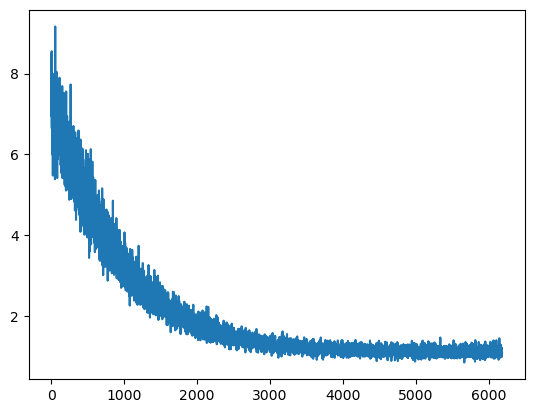

In [ ]:
y =  [6.96344518661499, 8.478178977966309, 8.031213760375977, 7.775172710418701, 7.684081077575684, 7.812692165374756, 7.222414970397949, 8.550899505615234, 7.162952423095703, 6.64335823059082, 7.411767959594727, 6.814299583435059, 6.728523254394531, 6.825058937072754, 6.786489486694336, 7.337530136108398, 7.162762641906738, 6.749831199645996, 6.701704502105713, 7.559144973754883, 5.987534999847412, 7.031806945800781, 7.3392252922058105, 5.472332000732422, 6.950873851776123, 7.75563907623291, 6.559565544128418, 7.1634697914123535, 7.075459957122803, 6.989999294281006, 7.806390762329102, 7.2844438552856445, 7.467081069946289, 7.9877471923828125, 7.892292022705078, 6.876763343811035, 6.421102046966553, 7.725929260253906, 6.762609958648682, 6.8891987800598145, 7.308102130889893, 6.895625114440918, 5.950884819030762, 7.678342819213867, 6.6792893409729, 7.6307854652404785, 7.665252685546875, 6.85084867477417, 7.248063564300537, 5.704400062561035, 7.1221184730529785, 6.463203430175781, 5.382711887359619, 7.461936950683594, 6.110650539398193, 7.221015930175781, 9.164175987243652, 6.954441547393799, 7.119122505187988, 7.149068355560303, 6.948007106781006, 7.725737571716309, 7.044277191162109, 6.906317710876465, 7.874186992645264, 7.203324317932129, 6.7472429275512695, 7.0570526123046875, 7.609316825866699, 6.19416618347168, 7.06606388092041, 5.679102420806885, 7.817219257354736, 7.903086185455322, 8.04203987121582, 7.348897457122803, 5.8932671546936035, 6.522552013397217, 7.030762195587158, 6.943545818328857, 7.349847793579102, 6.658869743347168, 6.9901556968688965, 5.411484718322754, 7.695749759674072, 6.681063652038574, 6.856794357299805, 6.493180751800537, 6.118709564208984, 5.877779006958008, 7.0930070877075195, 6.277419090270996, 7.583958148956299, 7.358791828155518, 7.00377893447876, 7.323091506958008, 7.369081020355225, 6.38224983215332, 6.539475440979004, 6.454710483551025, 6.835045337677002, 7.218237400054932, 6.324162006378174, 7.4602203369140625, 6.63964319229126, 6.408634662628174, 6.255028247833252, 6.78077507019043, 7.757230281829834, 7.039156913757324, 6.048710823059082, 6.688206672668457, 6.041483402252197, 7.295454978942871, 7.895382881164551, 6.883059024810791, 7.815378189086914, 7.349575996398926, 6.501001358032227, 6.265654563903809, 5.999298572540283, 7.115990161895752, 6.06854248046875, 7.357720375061035, 6.3548583984375, 7.628332138061523, 6.796360015869141, 6.145448684692383, 6.506127834320068, 7.556623935699463, 5.734267711639404, 6.1997551918029785, 6.3894195556640625, 6.709185600280762, 7.4364519119262695, 6.700699329376221, 5.540643215179443, 6.274458885192871, 7.516002655029297, 6.7491021156311035, 5.914042949676514, 6.297259330749512, 6.843207359313965, 6.596498966217041, 6.312675476074219, 6.326717376708984, 6.277308464050293, 6.612799644470215, 6.224153995513916, 7.009380340576172, 6.278770923614502, 6.683865070343018, 7.688533782958984, 5.7590508460998535, 7.106396675109863, 5.409297466278076, 6.315556526184082, 6.381097316741943, 6.353538513183594, 5.463927268981934, 6.498362064361572, 5.804358005523682, 6.5236310958862305, 6.390630722045898, 6.367866039276123, 6.52208137512207, 5.948306560516357, 5.9102044105529785, 6.425958633422852, 7.285377502441406, 6.377626419067383, 7.295374870300293, 7.507955551147461, 5.5208024978637695, 6.618979454040527, 7.332126617431641, 7.050641059875488, 5.874780178070068, 6.452253341674805, 5.625290870666504, 6.766112327575684, 6.0171332359313965, 6.52626371383667, 7.071821689605713, 7.313085556030273, 5.246421813964844, 6.182668209075928, 7.509278774261475, 6.553197383880615, 6.9473090171813965, 6.473495006561279, 5.908753395080566, 6.66858434677124, 6.545281410217285, 6.2927470207214355, 6.226706027984619, 5.208486557006836, 6.409792423248291, 5.458967208862305, 7.321176052093506, 5.686251163482666, 6.427863121032715, 5.664461612701416, 5.101140022277832, 6.348268985748291, 7.37882137298584, 7.5546979904174805, 5.879974842071533, 5.678000450134277, 5.383902072906494, 5.686890602111816, 5.6263580322265625, 5.914288520812988, 6.2005391120910645, 6.305450439453125, 6.504055023193359, 6.054248809814453, 6.508790016174316, 6.7939453125, 6.94498348236084, 5.759027481079102, 6.814835071563721, 5.551129341125488, 5.515325546264648, 6.057438850402832, 5.898103713989258, 5.1258955001831055, 5.976993083953857, 5.190322399139404, 5.865670680999756, 5.599531650543213, 6.043792724609375, 6.224577903747559, 6.3683977127075195, 6.623701095581055, 6.118468284606934, 5.3851318359375, 5.743956089019775, 5.8553466796875, 6.137014389038086, 5.709890842437744, 5.843268394470215, 5.345373153686523, 6.108089923858643, 5.954537391662598, 5.69114875793457, 6.513533592224121, 6.603524208068848, 5.811009407043457, 4.874866962432861, 5.910210609436035, 5.413409233093262, 5.091054439544678, 6.817656993865967, 5.414255142211914, 6.294126033782959, 5.306254863739014, 5.313053131103516, 6.0759148597717285, 6.6068010330200195, 6.178002834320068, 5.345815658569336, 5.825680732727051, 5.5222063064575195, 5.705126762390137, 5.7714152336120605, 5.838064193725586, 7.728183746337891, 5.242692947387695, 5.583489418029785, 4.913696765899658, 5.604213714599609, 5.5652360916137695, 5.31072998046875, 5.621074199676514, 6.542457103729248, 6.424205780029297, 4.8924431800842285, 5.404712677001953, 5.505239486694336, 5.401838779449463, 5.811598777770996, 5.969015121459961, 5.380075454711914, 5.463394641876221, 5.974450588226318, 6.456656455993652, 5.352992057800293, 5.78671932220459, 5.184891700744629, 5.888470649719238, 6.213780403137207, 6.034384727478027, 5.356495380401611, 5.049895286560059, 6.180817127227783, 5.254560947418213, 4.951891899108887, 5.283487319946289, 4.983428955078125, 5.459700584411621, 5.84166145324707, 5.9638352394104, 5.141239166259766, 5.325550556182861, 6.700547695159912, 6.498950004577637, 5.128293991088867, 6.495841979980469, 5.301258087158203, 6.398119926452637, 5.767057418823242, 5.500363826751709, 5.037633895874023, 5.016763210296631, 5.129664897918701, 5.193098068237305, 4.824879169464111, 5.963118553161621, 5.179464340209961, 5.269064426422119, 5.506349563598633, 5.630640029907227, 5.765872955322266, 6.266831398010254, 4.873477935791016, 4.60734224319458, 5.4160685539245605, 5.517422199249268, 6.175021648406982, 6.542604923248291, 5.686040878295898, 5.605979919433594, 5.214854717254639, 5.840683937072754, 5.171933650970459, 6.343024253845215, 5.290045261383057, 5.067353248596191, 5.607280254364014, 6.126322269439697, 4.375588893890381, 6.101528644561768, 5.2597246170043945, 4.826084136962891, 4.684206485748291, 5.408850193023682, 5.877089500427246, 4.968619346618652, 5.280543804168701, 6.399167537689209, 5.537643909454346, 4.985157489776611, 5.166423797607422, 5.942473888397217, 5.258301734924316, 5.351254463195801, 5.719578266143799, 5.764494895935059, 5.301155090332031, 5.647496700286865, 5.351541042327881, 4.731362342834473, 5.585676193237305, 5.810275077819824, 4.7871599197387695, 5.708618640899658, 5.258798122406006, 5.662012100219727, 5.426892280578613, 5.549760818481445, 5.4751739501953125, 5.263490200042725, 4.999384880065918, 5.330747604370117, 6.589998245239258, 4.8505754470825195, 4.862068176269531, 5.184778690338135, 4.614188194274902, 5.539907455444336, 5.194981575012207, 4.507983207702637, 4.793898105621338, 5.4499664306640625, 4.8847126960754395, 5.169973373413086, 4.868256568908691, 4.849789619445801, 4.812310218811035, 5.370199680328369, 5.084904670715332, 4.77039909362793, 4.782466888427734, 4.581432342529297, 4.426068305969238, 5.433216571807861, 4.5320587158203125, 5.565593242645264, 4.7898173332214355, 4.684138774871826, 4.70042610168457, 4.0813798904418945, 6.364880084991455, 4.850615501403809, 5.253641605377197, 5.487566947937012, 4.97896671295166, 4.6028337478637695, 5.595829010009766, 5.05748987197876, 5.546597480773926, 5.569028377532959, 6.166707992553711, 4.928325653076172, 5.172940254211426, 4.903009414672852, 5.511653900146484, 4.996518135070801, 5.758869647979736, 5.976533889770508, 4.785552501678467, 4.531943321228027, 5.642641544342041, 5.278379440307617, 4.949889659881592, 5.4723334312438965, 5.456389904022217, 4.911638259887695, 4.371471881866455, 5.596763610839844, 4.271943092346191, 4.854118347167969, 5.526405334472656, 5.186020851135254, 5.089871406555176, 6.127067565917969, 5.311853885650635, 5.434410572052002, 4.613253116607666, 5.872724533081055, 5.18833065032959, 5.4450883865356445, 4.897459030151367, 5.262936592102051, 4.208807468414307, 5.153642654418945, 4.635024070739746, 5.410377025604248, 4.7269439697265625, 4.643431663513184, 4.583545207977295, 5.373342037200928, 4.916646957397461, 4.012823581695557, 4.258858680725098, 4.447046279907227, 4.983904838562012, 4.828067779541016, 4.410005569458008, 5.0071797370910645, 4.468712329864502, 5.320511817932129, 5.291177749633789, 4.9821672439575195, 4.947913646697998, 4.804985046386719, 4.982071399688721, 5.4044084548950195, 4.539946556091309, 5.30640172958374, 4.852119445800781, 5.327686309814453, 5.665165901184082, 4.393441200256348, 5.313315391540527, 4.016687393188477, 6.100975036621094, 5.016423225402832, 5.724332332611084, 4.558086395263672, 4.961730480194092, 5.442853927612305, 5.088676452636719, 4.351377010345459, 4.595564842224121, 5.698729991912842, 4.505859851837158, 4.969155311584473, 4.420820236206055, 5.263278007507324, 4.630433082580566, 4.4863691329956055, 4.9262213706970215, 5.274833679199219, 4.76996374130249, 4.479572296142578, 3.9406049251556396, 4.601100444793701, 4.965433597564697, 4.954517841339111, 4.0914387702941895, 6.011806964874268, 4.259349822998047, 5.555429935455322, 4.726722240447998, 4.2072954177856445, 4.785518646240234, 5.031301975250244, 4.664070129394531, 5.6928629875183105, 4.045224189758301, 4.8820390701293945, 5.010621547698975, 4.1682257652282715, 4.911210060119629, 5.452774524688721, 4.885822296142578, 4.240623950958252, 4.844171524047852, 3.4336800575256348, 4.839327812194824, 5.88189172744751, 4.704862117767334, 5.225197792053223, 4.501064777374268, 4.996038436889648, 5.263937473297119, 4.952658176422119, 4.452271938323975, 4.078365325927734, 4.395178318023682, 3.598015785217285, 5.013186454772949, 4.403299808502197, 4.786854267120361, 4.8176445960998535, 4.187700271606445, 4.626644134521484, 4.879737854003906, 4.306021213531494, 4.003897666931152, 4.014989376068115, 6.126039505004883, 5.592041015625, 5.833240509033203, 4.464784622192383, 3.7699265480041504, 3.9554219245910645, 4.696669578552246, 3.997866153717041, 4.3380351066589355, 4.743403434753418, 4.067358016967773, 5.015862941741943, 4.826316833496094, 4.583840370178223, 3.9484875202178955, 5.595742702484131, 5.6271281242370605, 4.491409778594971, 4.885841369628906, 4.431805610656738, 4.603395938873291, 4.916595458984375, 5.817840576171875, 4.7359418869018555, 4.893027305603027, 5.166034698486328, 4.585097789764404, 5.111243724822998, 5.017961025238037, 4.3581109046936035, 4.659071445465088, 4.691980361938477, 4.146137714385986, 5.436224460601807, 4.29549503326416, 4.148111820220947, 5.036195755004883, 5.279666900634766, 4.266149997711182, 4.855607986450195, 5.061260223388672, 4.704116344451904, 4.640912055969238, 4.346546173095703, 4.301530838012695, 4.068104267120361, 4.10650110244751, 4.185051918029785, 3.930407762527466, 4.410424709320068, 4.268744468688965, 4.433891296386719, 3.801257848739624, 4.65919303894043, 4.278076648712158, 4.641117572784424, 3.5782597064971924, 4.033762454986572, 4.109960556030273, 4.3274712562561035, 4.5799784660339355, 4.550046443939209, 5.3643035888671875, 4.216130256652832, 4.392114639282227, 4.873281955718994, 4.259233474731445, 4.667862415313721, 4.173401355743408, 4.288791179656982, 4.239603042602539, 4.368342876434326, 3.655153274536133, 3.9524807929992676, 4.410065174102783, 3.8593997955322266, 4.4006805419921875, 4.264730930328369, 4.034242630004883, 4.548162937164307, 4.309157848358154, 4.892021179199219, 4.111863613128662, 4.504727840423584, 4.284967422485352, 3.9256198406219482, 3.6955678462982178, 4.066183090209961, 4.535235404968262, 4.579719543457031, 4.375922203063965, 4.722647666931152, 3.8023314476013184, 4.989969730377197, 3.774372100830078, 3.81095552444458, 4.23606014251709, 3.8775463104248047, 4.359596252441406, 4.636247158050537, 3.7204787731170654, 3.7561962604522705, 4.560209274291992, 4.525544166564941, 4.076915740966797, 3.9600605964660645, 4.114063739776611, 3.947500228881836, 4.160676956176758, 4.927910327911377, 4.327636241912842, 4.660602569580078, 5.1042633056640625, 4.4543538093566895, 3.9310903549194336, 4.847146987915039, 4.570737361907959, 4.227141380310059, 4.744708061218262, 4.404662609100342, 4.39511251449585, 3.725221633911133, 3.3716554641723633, 4.621615409851074, 4.019441604614258, 3.4130825996398926, 4.0435919761657715, 4.496197700500488, 4.065616607666016, 4.044699668884277, 3.9173202514648438, 3.367069959640503, 4.55068302154541, 4.423427581787109, 4.158936977386475, 4.450035095214844, 4.575155735015869, 3.8002710342407227, 4.435887336730957, 3.677018165588379, 3.923142194747925, 3.9192843437194824, 4.55206823348999, 4.007903575897217, 3.69853138923645, 3.8633224964141846, 4.561324596405029, 4.522101879119873, 4.249879360198975, 3.715630531311035, 3.83052921295166, 3.525618076324463, 4.913657188415527, 4.199963569641113, 3.8251094818115234, 3.799940586090088, 5.15809965133667, 4.961727142333984, 4.101792335510254, 3.687069892883301, 4.420729160308838, 3.2457449436187744, 4.370312213897705, 3.6009535789489746, 3.9935412406921387, 3.668609380722046, 3.7468528747558594, 3.805044651031494, 3.673157215118408, 3.657288074493408, 3.008470296859741, 4.09572696685791, 3.6090846061706543, 4.128345489501953, 4.39164924621582, 4.884973526000977, 4.2532782554626465, 4.38219690322876, 4.663307189941406, 3.626493215560913, 3.9281978607177734, 3.703545570373535, 4.376095771789551, 3.210336446762085, 4.144608974456787, 3.323895215988159, 3.8686013221740723, 3.304478168487549, 3.5642921924591064, 4.174406051635742, 4.1418137550354, 3.920187473297119, 4.291683673858643, 4.335116386413574, 3.965944766998291, 4.1368021965026855, 3.691866874694824, 3.5247206687927246, 3.2170960903167725, 3.6486289501190186, 3.3736021518707275, 4.114785194396973, 3.6658949851989746, 3.5389366149902344, 3.6431117057800293, 3.8347113132476807, 3.887964963912964, 4.621499538421631, 3.971160411834717, 4.0755133628845215, 3.78242826461792, 4.132761001586914, 3.9415063858032227, 3.750858783721924, 3.428483247756958, 4.632371425628662, 3.6106655597686768, 4.383276462554932, 3.527432441711426, 3.515613317489624, 3.4644758701324463, 3.796792984008789, 4.281844615936279, 3.223316192626953, 3.524578809738159, 3.8631253242492676, 4.429502964019775, 3.552842617034912, 4.297012805938721, 4.297607898712158, 3.816979169845581, 4.006829738616943, 2.870717763900757, 3.757761001586914, 3.3298535346984863, 4.569247245788574, 4.233399868011475, 3.601292610168457, 3.7242603302001953, 4.019864082336426, 3.8145222663879395, 3.9092366695404053, 4.144130706787109, 4.495788097381592, 3.4278087615966797, 3.813570022583008, 3.706376075744629, 3.4058845043182373, 4.104614734649658, 3.7785513401031494, 3.769019365310669, 3.8890204429626465, 3.3481898307800293, 3.4764649868011475, 3.6324703693389893, 3.5832903385162354, 3.222550630569458, 3.8733434677124023, 3.1194264888763428, 3.957136869430542, 4.016373157501221, 3.645601272583008, 3.432983875274658, 4.031253814697266, 3.74001145362854, 4.2812395095825195, 3.3800535202026367, 3.307041645050049, 4.3387250900268555, 3.9141154289245605, 3.4204530715942383, 4.132296562194824, 4.33394193649292, 3.5290229320526123, 4.210078716278076, 3.295013904571533, 4.242359638214111, 3.5166168212890625, 4.421407699584961, 3.4526777267456055, 3.4019646644592285, 4.229543209075928, 3.548248529434204, 3.328555107116699, 3.614636182785034, 3.8697025775909424, 3.56648325920105, 4.33553409576416, 3.6033194065093994, 3.0564396381378174, 3.3178999423980713, 4.18996000289917, 3.748471736907959, 3.745159149169922, 4.370950698852539, 3.6654090881347656, 3.5523762702941895, 3.640657424926758, 3.730159044265747, 3.8131320476531982, 3.3871562480926514, 3.366610050201416, 3.6724894046783447, 4.85157585144043, 3.911592721939087, 4.029898643493652, 3.3608598709106445, 3.2237396240234375, 3.6705212593078613, 3.2026147842407227, 3.352106809616089, 3.298752546310425, 3.4333319664001465, 4.13826847076416, 3.0504696369171143, 3.7980451583862305, 3.5550050735473633, 3.7656283378601074, 3.7988533973693848, 3.0138723850250244, 4.081099033355713, 3.0822551250457764, 3.592033624649048, 3.8092541694641113, 3.427900791168213, 3.5317654609680176, 3.7345566749572754, 4.275888442993164, 3.8208956718444824, 3.5540995597839355, 3.727215528488159, 3.5693297386169434, 3.3217575550079346, 3.7788336277008057, 3.7091777324676514, 3.724107265472412, 3.239217758178711, 3.2397942543029785, 3.6538214683532715, 3.684755563735962, 3.47006893157959, 3.3740451335906982, 3.37146258354187, 3.8346123695373535, 3.896914005279541, 4.055364608764648, 3.589653968811035, 3.506418466567993, 4.04185152053833, 4.021148681640625, 3.651533365249634, 4.420607566833496, 3.948516368865967, 3.3817391395568848, 3.2727832794189453, 2.9319961071014404, 3.599104642868042, 3.3320631980895996, 3.61130952835083, 3.903961420059204, 3.614215612411499, 3.2473034858703613, 4.137967109680176, 3.2862749099731445, 3.5528697967529297, 3.7853105068206787, 3.205940008163452, 3.2892117500305176, 3.6370797157287598, 3.08743953704834, 3.6732497215270996, 3.010951042175293, 3.4593777656555176, 3.065786600112915, 2.97493839263916, 3.548255443572998, 3.230526924133301, 3.4751527309417725, 3.405726909637451, 3.416659355163574, 3.461846113204956, 2.8942155838012695, 3.1054794788360596, 3.4581005573272705, 3.1034910678863525, 3.2318341732025146, 3.3950915336608887, 3.503671407699585, 3.1787593364715576, 3.8625309467315674, 3.1270315647125244, 3.5721609592437744, 3.583998918533325, 3.1824750900268555, 4.130578994750977, 2.881446123123169, 3.372925043106079, 3.402956485748291, 3.470311403274536, 3.3153154850006104, 3.4666285514831543, 2.8381235599517822, 3.3743934631347656, 3.086927652359009, 3.3236680030822754, 3.1170859336853027, 3.0776326656341553, 3.5832507610321045, 3.279613494873047, 3.8376917839050293, 3.7190966606140137, 3.373182773590088, 3.2885143756866455, 3.3533835411071777, 3.3740110397338867, 3.6179990768432617, 2.69321608543396, 3.257709503173828, 3.1112122535705566, 3.313971519470215, 3.716383457183838, 3.363718032836914, 3.5883586406707764, 3.6314563751220703, 3.5186233520507812, 3.0669820308685303, 3.656571626663208, 3.712092161178589, 2.973076105117798, 3.7154650688171387, 2.916360855102539, 3.727600336074829, 2.728294849395752, 3.3413028717041016, 3.321682929992676, 3.5814931392669678, 3.1557345390319824, 3.009239673614502, 3.538898229598999, 3.4292073249816895, 3.0985255241394043, 2.8033576011657715, 3.0406620502471924, 2.822556495666504, 3.3537023067474365, 3.419044017791748, 3.6282739639282227, 3.0058717727661133, 3.5276482105255127, 3.1985387802124023, 3.2125723361968994, 3.68300724029541, 3.062678575515747, 3.3755297660827637, 3.2586991786956787, 3.5250139236450195, 2.9863226413726807, 3.0710361003875732, 3.1188056468963623, 3.5846121311187744, 3.9148614406585693, 3.0845723152160645, 4.0672993659973145, 3.6033339500427246, 3.58868408203125, 2.716679096221924, 2.884281873703003, 3.174708127975464, 3.6039466857910156, 3.1073367595672607, 3.3790040016174316, 3.8129661083221436, 3.600513458251953, 2.853626012802124, 3.379045009613037, 3.408003568649292, 3.1399471759796143, 3.3299574851989746, 3.6145424842834473, 2.6324515342712402, 3.606306314468384, 3.0215542316436768, 3.003024101257324, 3.143669366836548, 3.084716796875, 2.650118827819824, 2.9765102863311768, 3.691969394683838, 2.780503273010254, 3.141958236694336, 3.4998934268951416, 3.4978437423706055, 3.3601653575897217, 3.6455771923065186, 3.4795429706573486, 3.3756673336029053, 3.352421998977661, 3.3189992904663086, 2.7263295650482178, 3.033984899520874, 3.3555996417999268, 2.955949306488037, 3.375389814376831, 2.600637435913086, 3.079756021499634, 3.185720443725586, 2.8715853691101074, 3.019531726837158, 3.5443925857543945, 3.1983444690704346, 3.29656982421875, 3.1219282150268555, 2.7940874099731445, 3.479583740234375, 3.156296491622925, 3.4515373706817627, 2.976148843765259, 2.8538315296173096, 2.959357976913452, 3.158202648162842, 3.1212127208709717, 3.0559794902801514, 2.997410535812378, 3.1485605239868164, 3.1390702724456787, 2.6436078548431396, 3.4835824966430664, 2.715545892715454, 3.079958438873291, 2.891740322113037, 2.9228227138519287, 2.4880876541137695, 3.1419520378112793, 3.168635129928589, 2.2551047801971436, 3.160996913909912, 3.4215805530548096, 3.466745138168335, 3.2352230548858643, 3.657362461090088, 2.6532034873962402, 3.0384039878845215, 3.2476892471313477, 3.1651647090911865, 3.150625228881836, 3.051408529281616, 3.044999599456787, 3.2713403701782227, 2.9936304092407227, 2.556796073913574, 2.962029457092285, 3.269406795501709, 3.046995162963867, 2.8406503200531006, 3.1292502880096436, 2.7597720623016357, 3.1811952590942383, 2.6254868507385254, 2.804133653640747, 2.9307861328125, 2.885507583618164, 2.692554473876953, 2.496004581451416, 2.8477516174316406, 3.1850385665893555, 3.2720179557800293, 3.222459316253662, 2.943113327026367, 3.6339635848999023, 2.94329833984375, 3.0519165992736816, 2.5150704383850098, 2.605797290802002, 2.7593705654144287, 3.0057313442230225, 3.450507164001465, 2.617405652999878, 3.0439295768737793, 2.8334271907806396, 2.5885462760925293, 2.610279083251953, 2.954901933670044, 3.071751832962036, 2.804926872253418, 2.955753803253174, 2.7810587882995605, 3.146115303039551, 3.2026865482330322, 2.875187397003174, 3.065997838973999, 3.122178077697754, 3.165614128112793, 2.7688024044036865, 3.049726963043213, 2.499114751815796, 2.3776843547821045, 2.914846897125244, 2.477994203567505, 2.969364643096924, 3.0607213973999023, 3.2055184841156006, 2.715057134628296, 2.8626861572265625, 2.4317359924316406, 2.6666789054870605, 3.3448095321655273, 2.5305182933807373, 2.9820051193237305, 2.7562239170074463, 2.673938035964966, 3.2068212032318115, 2.7324788570404053, 2.6537563800811768, 3.126737117767334, 3.199592351913452, 2.6779229640960693, 2.4923532009124756, 2.972113847732544, 2.5879669189453125, 2.499532699584961, 3.019636869430542, 2.7477340698242188, 2.8277759552001953, 3.466021776199341, 3.352688789367676, 2.321033477783203, 3.1576008796691895, 2.6512598991394043, 3.124093770980835, 3.0503921508789062, 3.0724644660949707, 2.4579203128814697, 3.1799869537353516, 3.051039457321167, 3.2273976802825928, 3.1091909408569336, 2.8791565895080566, 2.773944854736328, 2.775559902191162, 3.062281847000122, 2.2731659412384033, 3.1520485877990723, 2.963150978088379, 2.9407410621643066, 2.530043840408325, 2.8080813884735107, 3.0457775592803955, 3.1750667095184326, 2.6271519660949707, 2.621185064315796, 3.1817874908447266, 2.643892765045166, 2.7890610694885254, 2.450350522994995, 2.7955262660980225, 2.7664794921875, 3.7343335151672363, 2.812140941619873, 2.756923198699951, 2.8389182090759277, 2.5550894737243652, 2.793052911758423, 2.4736666679382324, 2.6013948917388916, 3.102048397064209, 2.3188531398773193, 3.089801549911499, 2.7760024070739746, 2.4999852180480957, 2.5762431621551514, 2.918459892272949, 2.919201374053955, 2.536095142364502, 2.60863995552063, 2.8271496295928955, 2.277890682220459, 2.562289237976074, 2.6674065589904785, 2.7021193504333496, 2.8224740028381348, 2.5079238414764404, 2.528278350830078, 2.622915506362915, 3.0743319988250732, 2.92797589302063, 3.170037269592285, 3.0386977195739746, 2.5735726356506348, 2.279674530029297, 2.387368679046631, 2.5101797580718994, 2.7132954597473145, 2.8538153171539307, 3.105893850326538, 2.9940426349639893, 3.0538330078125, 3.1496613025665283, 2.659158945083618, 2.83327054977417, 2.6268043518066406, 2.5377838611602783, 2.511155843734741, 2.58543062210083, 2.848845958709717, 2.961643695831299, 2.971574306488037, 2.4017624855041504, 3.0438175201416016, 2.71170711517334, 2.476923942565918, 2.7039780616760254, 2.799065351486206, 2.9093172550201416, 3.3072967529296875, 2.6547582149505615, 2.896467924118042, 2.8531646728515625, 2.568756103515625, 3.0500028133392334, 2.696282386779785, 2.2038402557373047, 2.756190061569214, 2.801386594772339, 2.232241153717041, 2.574695587158203, 2.923105478286743, 2.448382616043091, 2.6699137687683105, 2.8800570964813232, 2.6842315196990967, 3.1205246448516846, 2.593007802963257, 2.8690876960754395, 2.404592752456665, 2.57826566696167, 2.960090160369873, 2.16426420211792, 2.781440258026123, 2.4521913528442383, 2.6017494201660156, 2.5041627883911133, 2.2577614784240723, 2.6606764793395996, 2.729031562805176, 2.490633964538574, 2.3709583282470703, 2.4197871685028076, 2.640594959259033, 2.327897548675537, 2.3496241569519043, 2.4366140365600586, 2.4878439903259277, 2.8690853118896484, 2.733394145965576, 2.592010498046875, 2.2593741416931152, 2.928088665008545, 2.834078550338745, 2.2854793071746826, 2.1980440616607666, 2.873148202896118, 2.787360429763794, 2.2140069007873535, 2.730367660522461, 2.527665615081787, 2.6874022483825684, 2.8094165325164795, 2.9680593013763428, 2.9802255630493164, 2.6020731925964355, 2.691568374633789, 2.404878616333008, 2.652487277984619, 2.4767048358917236, 2.8938560485839844, 2.0803050994873047, 2.878666400909424, 2.978135347366333, 2.4238157272338867, 2.614561080932617, 2.3917970657348633, 2.9240546226501465, 2.7578835487365723, 2.3700549602508545, 2.746462821960449, 2.656057834625244, 2.6053693294525146, 2.3929240703582764, 2.1659066677093506, 2.7693285942077637, 2.1972286701202393, 2.4687869548797607, 3.2576563358306885, 2.0729470252990723, 2.134040117263794, 2.692765712738037, 2.587131977081299, 2.56430721282959, 2.0925838947296143, 2.8982348442077637, 2.3391573429107666, 2.8804736137390137, 2.3318657875061035, 2.2880401611328125, 2.438153028488159, 2.149475336074829, 2.97792387008667, 2.4495797157287598, 2.363731622695923, 2.8465981483459473, 2.4649600982666016, 1.9544837474822998, 2.381758689880371, 2.478888988494873, 2.2703697681427, 2.6775572299957275, 2.3113584518432617, 2.221625804901123, 2.188972234725952, 2.903824806213379, 2.9831976890563965, 2.495211362838745, 2.1974081993103027, 2.3488757610321045, 2.2945826053619385, 2.3395802974700928, 2.503511667251587, 2.823340892791748, 2.3284859657287598, 2.646702527999878, 2.3172874450683594, 2.483186721801758, 2.4198684692382812, 2.1619813442230225, 2.2863051891326904, 2.3026819229125977, 2.3038604259490967, 2.8401095867156982, 2.601787567138672, 2.336207628250122, 2.271458387374878, 2.670058012008667, 2.0853052139282227, 2.2306313514709473, 2.4706759452819824, 2.6464297771453857, 2.4378175735473633, 2.319432258605957, 2.3232932090759277, 2.057624340057373, 2.7553653717041016, 2.3959720134735107, 2.1741020679473877, 2.684889554977417, 2.291459321975708, 2.6889326572418213, 2.4603705406188965, 2.1389334201812744, 2.1022894382476807, 2.6517603397369385, 2.367600917816162, 2.6709342002868652, 2.0399208068847656, 2.329648494720459, 2.4335851669311523, 2.6180062294006348, 2.2529988288879395, 2.648745059967041, 2.583167791366577, 2.0620055198669434, 3.067387342453003, 3.135874032974243, 2.4297244548797607, 2.4371373653411865, 2.204319953918457, 2.425706386566162, 2.634115219116211, 2.7161645889282227, 2.562486171722412, 2.406360149383545, 2.1922340393066406, 2.364459991455078, 2.517164707183838, 2.493199348449707, 2.607149362564087, 2.4435384273529053, 2.976586103439331, 2.0576212406158447, 2.5525424480438232, 2.29946231842041, 2.3650856018066406, 2.0117571353912354, 2.7771193981170654, 2.6893248558044434, 2.1982648372650146, 2.6920809745788574, 2.7132022380828857, 2.3280539512634277, 2.6555631160736084, 2.8249077796936035, 2.2282161712646484, 2.1521670818328857, 2.2848074436187744, 2.40812611579895, 2.46332049369812, 2.22109317779541, 2.520671844482422, 2.2990565299987793, 2.522623062133789, 2.4546384811401367, 2.4684250354766846, 2.3796539306640625, 2.262442111968994, 2.568347215652466, 2.494311571121216, 2.350085496902466, 2.4812822341918945, 2.578817844390869, 2.7434840202331543, 2.2934682369232178, 2.99544095993042, 2.1311910152435303, 1.9533480405807495, 2.372392416000366, 2.227628469467163, 2.2775025367736816, 1.8986389636993408, 2.7445502281188965, 2.283482313156128, 2.120681047439575, 2.1240999698638916, 2.3115181922912598, 1.9292712211608887, 2.145265817642212, 2.5440561771392822, 1.9719854593276978, 2.2145256996154785, 2.6136279106140137, 2.2512009143829346, 2.391310930252075, 2.197770833969116, 2.120210886001587, 2.2003941535949707, 2.433624505996704, 2.288978099822998, 2.2107698917388916, 2.157362222671509, 2.672983407974243, 2.8300185203552246, 2.2528750896453857, 2.0163040161132812, 2.346205472946167, 2.74334979057312, 2.1035966873168945, 2.2454705238342285, 2.4979989528656006, 2.4107236862182617, 2.361055850982666, 2.700338125228882, 2.0029683113098145, 2.0988430976867676, 2.452457904815674, 2.25422739982605, 2.1114089488983154, 2.4256722927093506, 2.2838544845581055, 2.21431040763855, 2.631533145904541, 2.30218243598938, 2.7303695678710938, 2.191236972808838, 2.4602866172790527, 2.4926552772521973, 2.2446484565734863, 2.4242289066314697, 2.1775457859039307, 2.0857338905334473, 2.2362186908721924, 2.097032070159912, 2.5806939601898193, 2.1864564418792725, 1.9167118072509766, 2.3362205028533936, 2.1562588214874268, 2.2771737575531006, 2.3805887699127197, 2.7392940521240234, 2.3588197231292725, 2.3097751140594482, 2.2341320514678955, 2.0885095596313477, 2.1689867973327637, 2.431140661239624, 2.1879384517669678, 2.496403932571411, 2.6711184978485107, 2.274186611175537, 2.161609411239624, 2.21118426322937, 2.329793930053711, 2.25524640083313, 2.3672947883605957, 2.2716355323791504, 2.3423190116882324, 2.170444965362549, 2.2143023014068604, 2.2585084438323975, 1.984906554222107, 2.165154218673706, 2.088420867919922, 2.388596296310425, 2.2291338443756104, 2.159541130065918, 2.2247235774993896, 2.314455270767212, 2.0083651542663574, 2.3700509071350098, 2.2794642448425293, 1.986886978149414, 2.1215758323669434, 2.63562273979187, 2.377703905105591, 2.0340535640716553, 2.4310693740844727, 2.359862804412842, 2.086092472076416, 2.189047336578369, 2.420057535171509, 2.445538282394409, 2.162468671798706, 2.306112289428711, 2.447784900665283, 2.0999581813812256, 2.2582738399505615, 2.1278865337371826, 2.0999364852905273, 2.0343823432922363, 2.3179781436920166, 2.2699296474456787, 2.2993500232696533, 1.7779502868652344, 1.900888204574585, 2.169264554977417, 2.377117395401001, 2.285655975341797, 1.8213669061660767, 2.301649332046509, 1.9801783561706543, 2.069580554962158, 2.036550998687744, 2.1511874198913574, 2.2627336978912354, 1.7697503566741943, 2.1684422492980957, 2.373256206512451, 2.580951690673828, 2.229203462600708, 2.247581958770752, 2.1595072746276855, 2.062770366668701, 2.1985549926757812, 2.575698137283325, 1.9491369724273682, 2.1063454151153564, 1.8320808410644531, 2.1352133750915527, 2.408259153366089, 2.1866345405578613, 2.0685975551605225, 2.0600104331970215, 2.1527717113494873, 2.1467714309692383, 2.0774765014648438, 2.112184524536133, 2.2749664783477783, 1.9817982912063599, 2.105807065963745, 2.095592737197876, 1.9976673126220703, 2.1450648307800293, 2.372405529022217, 1.937911868095398, 2.2587904930114746, 2.0247840881347656, 1.8567386865615845, 2.08558988571167, 1.9186593294143677, 1.8283394575119019, 1.9251728057861328, 2.2911558151245117, 2.2637345790863037, 2.215698480606079, 2.1686720848083496, 2.053314447402954, 1.9632532596588135, 1.5938010215759277, 2.1659369468688965, 2.2602829933166504, 2.1348280906677246, 2.2337212562561035, 2.174999713897705, 1.9769346714019775, 2.347262382507324, 2.1310949325561523, 1.9840017557144165, 1.9754890203475952, 1.8401962518692017, 2.1846981048583984, 1.7344729900360107, 2.39192533493042, 2.256856679916382, 1.8639339208602905, 1.9218463897705078, 1.933161973953247, 2.39949369430542, 2.1723906993865967, 2.0480306148529053, 2.1873862743377686, 2.1433374881744385, 1.8233287334442139, 2.0084550380706787, 1.9777421951293945, 2.4255919456481934, 2.003469467163086, 2.131096839904785, 2.1553924083709717, 2.5978987216949463, 2.0457489490509033, 2.0854873657226562, 2.241877555847168, 2.2880406379699707, 1.9614239931106567, 1.7559800148010254, 1.9105784893035889, 2.12306809425354, 1.9713281393051147, 2.107909917831421, 2.5916502475738525, 2.211547374725342, 2.280043840408325, 2.0843756198883057, 2.0592734813690186, 1.9400867223739624, 2.1517536640167236, 2.3812599182128906, 2.0741472244262695, 2.3740360736846924, 2.176104784011841, 2.0113985538482666, 2.040224075317383, 2.0439882278442383, 2.1134445667266846, 2.235724449157715, 2.174541711807251, 1.9590619802474976, 2.219644546508789, 2.266273260116577, 2.105696201324463, 1.946869134902954, 1.639632225036621, 2.1631977558135986, 1.8657431602478027, 2.4106173515319824, 1.913179636001587, 2.5049190521240234, 1.8808600902557373, 1.8967218399047852, 2.0477898120880127, 1.9923856258392334, 2.0983264446258545, 2.016075849533081, 1.78793203830719, 1.7780101299285889, 1.775697112083435, 2.029636859893799, 2.3505709171295166, 2.0443241596221924, 2.109876871109009, 1.9620330333709717, 2.050084114074707, 1.921457290649414, 1.977802038192749, 2.1692628860473633, 1.685233473777771, 2.01528263092041, 1.9272559881210327, 2.3511719703674316, 2.0636167526245117, 2.1437795162200928, 1.8778666257858276, 1.931312084197998, 2.06564998626709, 2.1613731384277344, 2.032304048538208, 1.7749111652374268, 2.152034282684326, 2.165273427963257, 1.9642995595932007, 1.9604970216751099, 2.063629388809204, 1.754706621170044, 2.3246312141418457, 2.1123340129852295, 1.9262299537658691, 2.489215850830078, 2.100080966949463, 1.901800513267517, 1.8793026208877563, 1.840907096862793, 1.8488130569458008, 2.094287157058716, 1.9054621458053589, 2.366931915283203, 2.0823473930358887, 2.091536283493042, 2.1289455890655518, 1.967659592628479, 2.063478946685791, 1.915886402130127, 2.235976457595825, 2.0347743034362793, 2.0431997776031494, 1.9403555393218994, 2.0148513317108154, 2.1674704551696777, 2.024003028869629, 1.8614445924758911, 1.831182837486267, 2.102346658706665, 1.7798829078674316, 1.5474973917007446, 2.1373510360717773, 2.2465667724609375, 2.281191349029541, 1.9936809539794922, 1.9574710130691528, 2.1202404499053955, 1.6093870401382446, 2.1051504611968994, 2.2819974422454834, 2.2249577045440674, 2.0402395725250244, 1.8128758668899536, 1.948517918586731, 2.0151381492614746, 1.9842257499694824, 2.0216128826141357, 1.8488115072250366, 2.1349799633026123, 1.9568183422088623, 1.887176275253296, 1.8844863176345825, 1.8434383869171143, 2.0449342727661133, 1.9552080631256104, 2.0441086292266846, 2.114074468612671, 1.8972139358520508, 2.021819591522217, 1.8972554206848145, 2.1969404220581055, 1.8376755714416504, 1.7831060886383057, 1.9588884115219116, 1.9404546022415161, 1.7254664897918701, 1.8255795240402222, 2.005218267440796, 2.2199108600616455, 2.1050775051116943, 1.9835599660873413, 2.132631301879883, 2.029841423034668, 1.8461474180221558, 1.9947125911712646, 1.945103645324707, 1.9637126922607422, 1.7167596817016602, 1.8229373693466187, 1.7719550132751465, 2.3129475116729736, 2.0642590522766113, 2.350177049636841, 1.772739052772522, 2.225586414337158, 1.8155179023742676, 2.061302661895752, 1.8532084226608276, 1.6807910203933716, 2.086989641189575, 2.0242514610290527, 1.7462483644485474, 1.8239140510559082, 1.757299780845642, 1.7825571298599243, 2.0910286903381348, 2.03812575340271, 1.6058300733566284, 1.8584587574005127, 1.8768070936203003, 2.0100772380828857, 1.7863562107086182, 1.6223891973495483, 1.8882970809936523, 1.9176907539367676, 1.8164530992507935, 2.000063419342041, 1.7095775604248047, 2.0570168495178223, 1.7456527948379517, 2.007568120956421, 1.543239951133728, 1.6244823932647705, 2.1005430221557617, 2.1844329833984375, 1.846555233001709, 1.7087990045547485, 2.2881882190704346, 1.8783057928085327, 2.251373767852783, 2.216101884841919, 1.7604209184646606, 1.7166889905929565, 2.072312355041504, 1.6897040605545044, 1.8185093402862549, 1.609198808670044, 1.6665291786193848, 1.5438789129257202, 2.092359781265259, 1.6955068111419678, 2.146885395050049, 1.6544489860534668, 2.0596768856048584, 1.9424089193344116, 2.040081024169922, 1.8588180541992188, 1.9015897512435913, 2.046058177947998, 1.9236353635787964, 1.8267357349395752, 1.8703358173370361, 1.8328055143356323, 1.9733442068099976, 1.8891561031341553, 1.7345553636550903, 2.2513084411621094, 2.0364906787872314, 1.6685515642166138, 2.121368885040283, 1.7566640377044678, 1.8444175720214844, 1.683105707168579, 1.6088061332702637, 1.834519863128662, 1.7291808128356934, 2.1112451553344727, 1.7611851692199707, 2.0753591060638428, 2.12017560005188, 1.9154313802719116, 1.6892552375793457, 1.792297601699829, 1.9281349182128906, 2.0077648162841797, 1.679410696029663, 2.022310495376587, 1.778841495513916, 1.755680799484253, 1.7272974252700806, 1.9018008708953857, 2.1357526779174805, 1.7562706470489502, 1.6670913696289062, 1.796897530555725, 1.8295376300811768, 1.7631621360778809, 2.143190860748291, 1.8806143999099731, 1.93982994556427, 2.0386970043182373, 1.747893214225769, 1.5461146831512451, 1.829906940460205, 1.7429957389831543, 1.8087520599365234, 1.7933461666107178, 1.7154312133789062, 1.74785315990448, 1.5125058889389038, 1.8512730598449707, 2.081469774246216, 1.940966248512268, 2.0245773792266846, 1.7503514289855957, 1.966844081878662, 1.7602744102478027, 1.5173218250274658, 1.8129504919052124, 1.7809112071990967, 1.7645471096038818, 1.6522102355957031, 1.7122520208358765, 1.6746411323547363, 1.7446945905685425, 2.2756781578063965, 1.9908461570739746, 1.6365094184875488, 1.8163881301879883, 1.868110179901123, 1.763908863067627, 1.8215761184692383, 1.6001590490341187, 1.7842448949813843, 1.8083757162094116, 1.8047735691070557, 1.838243007659912, 1.6444361209869385, 1.518686294555664, 2.0499958992004395, 1.8424564599990845, 1.8050460815429688, 1.6076387166976929, 1.8481135368347168, 1.8310222625732422, 1.8483487367630005, 1.8743616342544556, 1.8114922046661377, 2.0106406211853027, 1.9510282278060913, 1.9234435558319092, 1.777985692024231, 1.9501826763153076, 1.5290440320968628, 1.4500662088394165, 1.7038111686706543, 1.9656898975372314, 1.7660212516784668, 1.6969804763793945, 1.6332025527954102, 1.7201025485992432, 1.7806576490402222, 1.6992803812026978, 1.8008376359939575, 1.8075264692306519, 2.0380260944366455, 1.7315609455108643, 1.8559545278549194, 1.69636070728302, 1.5798017978668213, 1.754107117652893, 1.880506992340088, 1.5127373933792114, 1.672332525253296, 1.593902349472046, 1.708225965499878, 1.8858437538146973, 1.8869553804397583, 2.0185091495513916, 1.8680269718170166, 2.0194270610809326, 1.7306482791900635, 1.7337034940719604, 2.014543294906616, 1.528005838394165, 1.7798856496810913, 1.7398991584777832, 1.9082705974578857, 1.7839229106903076, 1.8283891677856445, 1.4005553722381592, 1.9115138053894043, 1.5473666191101074, 1.9801673889160156, 1.9763569831848145, 2.1058030128479004, 1.895487904548645, 1.6281189918518066, 1.6591811180114746, 1.7140406370162964, 1.811252236366272, 1.7948846817016602, 1.5976223945617676, 1.7506591081619263, 1.5548661947250366, 1.6452586650848389, 1.7073787450790405, 1.6823484897613525, 1.712293267250061, 1.780134916305542, 1.5330946445465088, 1.7448227405548096, 1.9771060943603516, 1.5886743068695068, 1.6791749000549316, 1.8594990968704224, 1.8852055072784424, 1.7226529121398926, 1.7662115097045898, 2.081901788711548, 1.6614850759506226, 1.8251218795776367, 1.393742561340332, 1.58523428440094, 1.8742802143096924, 1.7076300382614136, 2.0104541778564453, 1.969706416130066, 1.69642972946167, 1.8101904392242432, 1.6893341541290283, 1.608646273612976, 1.7778193950653076, 1.8256040811538696, 1.4759154319763184, 1.7072796821594238, 1.6301367282867432, 1.7804087400436401, 2.063473701477051, 1.7148487567901611, 1.885748028755188, 1.777206301689148, 1.9394655227661133, 1.6741814613342285, 1.7823431491851807, 1.566819429397583, 1.7777835130691528, 1.6944527626037598, 1.8626033067703247, 1.734508991241455, 1.5934584140777588, 1.6195333003997803, 2.132624864578247, 1.9939888715744019, 1.799816608428955, 1.6512075662612915, 1.7092387676239014, 1.7646818161010742, 1.5590453147888184, 1.7398605346679688, 1.5975302457809448, 1.4193145036697388, 1.5994762182235718, 1.6813122034072876, 1.5430551767349243, 1.6867589950561523, 1.692565679550171, 1.827088713645935, 1.4544627666473389, 1.9664709568023682, 1.6228090524673462, 1.8373944759368896, 1.707790493965149, 1.77912437915802, 1.6363722085952759, 1.5921303033828735, 1.7035852670669556, 1.6140655279159546, 1.5479745864868164, 1.615419626235962, 1.7901740074157715, 1.456876516342163, 1.4092282056808472, 1.5389297008514404, 1.6252212524414062, 1.6266872882843018, 2.0914297103881836, 1.9398958683013916, 1.7534605264663696, 1.7152618169784546, 1.814299464225769, 1.6427284479141235, 1.6803562641143799, 1.720481038093567, 1.500949740409851, 1.8373109102249146, 1.4893220663070679, 2.0324573516845703, 1.7260075807571411, 1.65385103225708, 1.7040207386016846, 1.4991859197616577, 1.6896603107452393, 1.566041111946106, 1.585362434387207, 1.683728814125061, 1.6784197092056274, 1.5024139881134033, 2.2336859703063965, 1.6434528827667236, 1.3276914358139038, 1.6152021884918213, 1.6896467208862305, 1.7319164276123047, 1.662640929222107, 1.6228394508361816, 1.6109815835952759, 1.6151823997497559, 1.5989559888839722, 1.5325368642807007, 1.8354952335357666, 1.6219215393066406, 1.903609037399292, 1.74417245388031, 1.6253257989883423, 1.6321074962615967, 1.616199016571045, 1.7187362909317017, 1.6116912364959717, 1.3703982830047607, 2.2186577320098877, 1.5365502834320068, 1.6346633434295654, 1.8537218570709229, 1.9552741050720215, 1.591381549835205, 1.756052851676941, 1.367034912109375, 1.4056832790374756, 1.591598629951477, 1.8383177518844604, 1.7951544523239136, 1.7739155292510986, 1.6687182188034058, 1.6645989418029785, 1.6942265033721924, 1.5611324310302734, 1.971208930015564, 1.6657116413116455, 1.4725658893585205, 1.6889588832855225, 1.8110456466674805, 1.6580861806869507, 1.5365395545959473, 1.3559000492095947, 1.711113691329956, 1.838568091392517, 1.741194248199463, 1.8524445295333862, 1.6689136028289795, 1.7109215259552002, 1.333428144454956, 1.515706181526184, 1.595529556274414, 1.7213282585144043, 1.5242794752120972, 1.542476773262024, 1.4671989679336548, 1.362312912940979, 1.9246022701263428, 1.6639795303344727, 1.7637786865234375, 1.4769477844238281, 1.673142671585083, 1.9033981561660767, 1.8292275667190552, 1.6388108730316162, 1.567360758781433, 1.6954803466796875, 1.4289321899414062, 1.671044111251831, 1.3886877298355103, 1.5504357814788818, 1.5207409858703613, 1.7497954368591309, 1.5904152393341064, 1.691361427307129, 1.8609727621078491, 1.6792877912521362, 1.7240132093429565, 1.6342774629592896, 1.610411524772644, 1.3859491348266602, 1.3572036027908325, 1.8501062393188477, 1.3550907373428345, 1.5720553398132324, 1.438227653503418, 1.5711063146591187, 1.5973987579345703, 1.632744312286377, 1.6022706031799316, 1.6282373666763306, 1.7709711790084839, 1.8469352722167969, 1.4134626388549805, 1.5451111793518066, 1.9291073083877563, 1.3753408193588257, 1.3712776899337769, 1.8282259702682495, 1.4548401832580566, 1.5520142316818237, 1.6656417846679688, 1.7160842418670654, 1.6931869983673096, 1.5182478427886963, 1.580736517906189, 1.4883629083633423, 1.615419626235962, 1.6499500274658203, 1.5598242282867432, 1.6253718137741089, 1.55488121509552, 1.5820997953414917, 1.4444937705993652, 1.5903205871582031, 1.5798568725585938, 1.7413156032562256, 1.746936559677124, 1.5068140029907227, 1.5475316047668457, 1.4031171798706055, 1.3779466152191162, 1.4153972864151, 1.625596523284912, 1.554430365562439, 1.5702930688858032, 1.602003812789917, 1.6383761167526245, 1.3620773553848267, 2.0197055339813232, 1.5902117490768433, 1.6113135814666748, 1.666882872581482, 1.4503649473190308, 1.5177520513534546, 1.2958462238311768, 1.4938299655914307, 1.6129363775253296, 1.3573824167251587, 1.6535338163375854, 1.5392504930496216, 1.4531517028808594, 1.6683216094970703, 1.6371904611587524, 1.7924182415008545, 1.4246771335601807, 1.4247395992279053, 1.5430752038955688, 1.7604846954345703, 1.5600899457931519, 1.9560670852661133, 1.642430305480957, 1.4621175527572632, 1.4906364679336548, 1.5537523031234741, 1.8429545164108276, 1.4555448293685913, 1.621354103088379, 1.502614974975586, 1.8361061811447144, 1.7802085876464844, 1.5734909772872925, 1.6200469732284546, 1.754594326019287, 1.6328139305114746, 1.4837968349456787, 1.6705210208892822, 1.5968153476715088, 1.5493189096450806, 1.4903521537780762, 1.607807993888855, 1.7624436616897583, 1.3761186599731445, 1.4776626825332642, 1.3577444553375244, 1.6106359958648682, 1.524579644203186, 1.5103685855865479, 1.4913009405136108, 1.6027312278747559, 1.7225079536437988, 1.5715361833572388, 1.770738959312439, 1.494789481163025, 1.7444156408309937, 1.460258960723877, 1.6826353073120117, 1.62033212184906, 1.6605421304702759, 1.4688743352890015, 1.620742917060852, 1.306172490119934, 1.3761807680130005, 1.4415295124053955, 1.551124095916748, 1.4423446655273438, 1.6482758522033691, 1.5855625867843628, 1.5858614444732666, 1.7075870037078857, 1.501428246498108, 1.7399200201034546, 1.6511783599853516, 1.371364951133728, 1.4988685846328735, 1.4839982986450195, 1.4215731620788574, 1.4675047397613525, 1.3654594421386719, 1.5890332460403442, 1.584021806716919, 1.5642346143722534, 1.6451960802078247, 1.5380245447158813, 1.42182457447052, 1.5335663557052612, 1.605355978012085, 1.46417236328125, 1.532383918762207, 1.7283761501312256, 1.7932283878326416, 1.3789119720458984, 1.6595900058746338, 1.5945570468902588, 1.5091853141784668, 1.5045855045318604, 1.4423950910568237, 1.3321272134780884, 1.2887910604476929, 1.8804516792297363, 1.2877516746520996, 1.54426908493042, 1.6195573806762695, 1.5247776508331299, 1.4781670570373535, 1.535008192062378, 1.441833734512329, 1.4732704162597656, 1.7478222846984863, 1.508780598640442, 1.7084548473358154, 1.5925275087356567, 1.5055092573165894, 1.731940746307373, 1.4366240501403809, 1.2227808237075806, 1.8094791173934937, 1.3515413999557495, 1.502544641494751, 1.3047071695327759, 1.4975247383117676, 1.541595697402954, 1.3735909461975098, 1.7907745838165283, 1.4055542945861816, 1.498671054840088, 1.6802518367767334, 1.4170318841934204, 1.495703935623169, 1.7998573780059814, 1.7066751718521118, 1.67225980758667, 1.533224105834961, 1.5345814228057861, 1.6662969589233398, 1.4956231117248535, 1.6146761178970337, 1.5552356243133545, 1.3090890645980835, 1.4986920356750488, 1.4777727127075195, 1.8370156288146973, 1.4877067804336548, 1.4291332960128784, 1.4359887838363647, 1.453453540802002, 1.5036365985870361, 1.465140700340271, 1.6619724035263062, 1.5376155376434326, 1.2827339172363281, 1.471144437789917, 1.324910044670105, 1.5649349689483643, 1.353773832321167, 1.3420817852020264, 1.7269606590270996, 1.790851354598999, 1.4492807388305664, 1.5345377922058105, 1.3670668601989746, 1.3554902076721191, 1.6020612716674805, 1.4511964321136475, 1.4004197120666504, 1.4344178438186646, 1.3403372764587402, 1.492020606994629, 1.5937353372573853, 1.3150599002838135, 1.4829959869384766, 1.5627260208129883, 1.6519476175308228, 1.724622368812561, 1.1707789897918701, 1.600358247756958, 1.7478605508804321, 1.5495675802230835, 1.5550386905670166, 1.5050405263900757, 1.5204472541809082, 1.3164006471633911, 1.1890407800674438, 1.4960991144180298, 1.4596607685089111, 1.5695383548736572, 1.524651050567627, 1.447926640510559, 1.6091103553771973, 1.3525575399398804, 1.417919635772705, 1.3052202463150024, 1.5114030838012695, 1.3938589096069336, 1.6486337184906006, 1.7164101600646973, 1.3733340501785278, 1.1730490922927856, 1.4341298341751099, 1.3824361562728882, 1.5790663957595825, 1.516167402267456, 1.4420863389968872, 1.5778170824050903, 1.662662386894226, 1.7516779899597168, 1.4777424335479736, 1.7756041288375854, 1.5728375911712646, 1.4918432235717773, 1.8080822229385376, 1.5463001728057861, 1.4425338506698608, 1.427493691444397, 1.4421228170394897, 1.6276286840438843, 1.353809118270874, 1.5587588548660278, 1.614113211631775, 1.505536437034607, 1.4778435230255127, 1.4632128477096558, 1.4349849224090576, 1.3779387474060059, 1.5440576076507568, 1.2921075820922852, 1.38911771774292, 1.56610906124115, 1.4793001413345337, 1.4877058267593384, 1.3716444969177246, 1.3580644130706787, 1.3281328678131104, 1.5774004459381104, 1.2696733474731445, 1.5882799625396729, 1.4348962306976318, 1.7082866430282593, 1.5320793390274048, 1.4611048698425293, 1.6592209339141846, 1.6863590478897095, 1.3846678733825684, 1.503023624420166, 1.4444102048873901, 1.2975126504898071, 1.629288911819458, 1.5263392925262451, 1.48863685131073, 1.4798545837402344, 1.3173627853393555, 1.4136470556259155, 1.4594826698303223, 1.3903396129608154, 1.5624650716781616, 1.4571082592010498, 1.5159423351287842, 1.555641770362854, 1.2970902919769287, 1.4355672597885132, 1.5972603559494019, 1.5002808570861816, 1.3096247911453247, 1.364370584487915, 1.2658827304840088, 1.3944355249404907, 1.431511640548706, 1.5260376930236816, 1.3113524913787842, 1.176175594329834, 1.5731343030929565, 1.4092798233032227, 1.363237738609314, 1.616668462753296, 1.3341423273086548, 1.542689561843872, 1.3441530466079712, 1.4771519899368286, 1.5896644592285156, 1.1464438438415527, 1.547457218170166, 1.4321221113204956, 1.3214876651763916, 1.3219506740570068, 1.4271049499511719, 1.1954927444458008, 1.5116515159606934, 1.5159094333648682, 1.4246894121170044, 1.275968074798584, 1.4077527523040771, 1.349158525466919, 1.5058470964431763, 1.4194526672363281, 1.3774268627166748, 1.53059720993042, 1.467361569404602, 1.6771847009658813, 1.4845035076141357, 1.3284125328063965, 1.6404294967651367, 1.236010193824768, 1.1765732765197754, 1.4741673469543457, 1.5934014320373535, 1.383953332901001, 1.1975955963134766, 1.4198232889175415, 1.5621384382247925, 1.5552161931991577, 1.5006237030029297, 1.397126317024231, 1.4487802982330322, 1.3020374774932861, 1.5447463989257812, 1.6790963411331177, 1.5362221002578735, 1.2671024799346924, 1.2755128145217896, 1.3812202215194702, 1.5517311096191406, 1.589385986328125, 1.4512944221496582, 1.5622237920761108, 1.4282245635986328, 1.604753851890564, 1.4262466430664062, 1.3939814567565918, 1.5764966011047363, 1.6643009185791016, 1.2798969745635986, 1.5122483968734741, 1.467776894569397, 1.3416194915771484, 1.4001359939575195, 1.4342371225357056, 1.4787942171096802, 1.4560298919677734, 1.4890245199203491, 1.4728021621704102, 1.5316733121871948, 1.3072901964187622, 1.3988049030303955, 1.6463251113891602, 1.4991534948349, 1.7404768466949463, 1.5392844676971436, 1.3595703840255737, 1.3183403015136719, 1.4048184156417847, 1.463533639907837, 1.4830565452575684, 1.4957455396652222, 1.3940000534057617, 1.227340817451477, 1.2421021461486816, 1.2674129009246826, 1.372254729270935, 1.427303433418274, 1.3857191801071167, 1.595239281654358, 1.5407624244689941, 1.446702003479004, 1.3619582653045654, 1.4322552680969238, 1.338371753692627, 1.4573578834533691, 1.301456093788147, 1.264816164970398, 1.3029454946517944, 1.285794973373413, 1.468528389930725, 1.300750732421875, 1.4346007108688354, 1.6293684244155884, 1.2749797105789185, 1.506528377532959, 1.4357503652572632, 1.6353421211242676, 1.2234479188919067, 1.5557758808135986, 1.264522910118103, 1.3871269226074219, 1.5660581588745117, 1.4181785583496094, 1.3614695072174072, 1.564423680305481, 1.4035723209381104, 1.5234733819961548, 1.1778981685638428, 1.295287847518921, 1.4721224308013916, 1.4746333360671997, 1.2366583347320557, 1.5249099731445312, 1.545807123184204, 1.3391356468200684, 1.0945147275924683, 1.3536394834518433, 1.3077672719955444, 1.2734578847885132, 1.703501582145691, 1.6151400804519653, 1.4943047761917114, 1.538374662399292, 1.3554792404174805, 1.2712187767028809, 1.5162583589553833, 1.5441923141479492, 1.2616395950317383, 1.3164818286895752, 1.5731940269470215, 1.2537121772766113, 1.321554183959961, 1.3347139358520508, 1.5536589622497559, 1.3422255516052246, 1.5002068281173706, 1.375562071800232, 1.352541446685791, 1.3268667459487915, 1.6123113632202148, 1.4693622589111328, 1.363333821296692, 1.4049564599990845, 1.3895606994628906, 1.2916821241378784, 1.2587158679962158, 1.5658855438232422, 1.3816096782684326, 1.3988640308380127, 1.373290777206421, 1.3714348077774048, 1.3909035921096802, 1.2144362926483154, 1.4048839807510376, 1.3294215202331543, 1.3160717487335205, 1.563743233680725, 1.4663324356079102, 1.248309850692749, 1.4381963014602661, 1.27195143699646, 1.5751144886016846, 1.406738042831421, 1.3110356330871582, 1.4078952074050903, 1.4346649646759033, 1.1906375885009766, 1.1932742595672607, 1.1502411365509033, 1.6442794799804688, 1.5032048225402832, 1.2746256589889526, 1.4768991470336914, 1.4049972295761108, 1.2063442468643188, 1.44212007522583, 1.4955155849456787, 1.2815399169921875, 1.4360512495040894, 1.4333823919296265, 1.451621174812317, 1.452771544456482, 1.5641534328460693, 1.3108165264129639, 1.442969799041748, 1.1345800161361694, 1.226516604423523, 1.4941691160202026, 1.1015803813934326, 1.4058043956756592, 1.306930422782898, 1.363683819770813, 1.1635901927947998, 1.2819719314575195, 1.4456382989883423, 1.350154995918274, 1.4913169145584106, 1.4368863105773926, 1.503619909286499, 1.1831960678100586, 1.3683210611343384, 1.3431322574615479, 1.3298814296722412, 1.2060784101486206, 1.4070147275924683, 1.2476590871810913, 1.4878628253936768, 1.4918452501296997, 1.4603371620178223, 1.3198217153549194, 1.2693722248077393, 1.2202398777008057, 1.586437702178955, 1.2046537399291992, 1.3798764944076538, 1.2139275074005127, 1.3100862503051758, 1.4491314888000488, 1.3623039722442627, 1.4113752841949463, 1.3907378911972046, 1.3278827667236328, 1.433409571647644, 1.3393622636795044, 1.2625592947006226, 1.2771012783050537, 1.2586466073989868, 1.2609726190567017, 1.2891111373901367, 1.408082127571106, 1.3619441986083984, 1.4383283853530884, 1.438382625579834, 1.4981509447097778, 1.438981056213379, 1.24653959274292, 1.2664577960968018, 1.3744820356369019, 1.4450472593307495, 1.5148859024047852, 1.558140754699707, 1.2435815334320068, 1.4600034952163696, 1.3336061239242554, 1.3192415237426758, 1.2762129306793213, 1.3015074729919434, 1.2283878326416016, 1.3024590015411377, 1.4302343130111694, 1.4085625410079956, 1.3694933652877808, 1.4089435338974, 1.3119183778762817, 1.6144368648529053, 1.2607523202896118, 1.2190468311309814, 1.3804715871810913, 1.4633647203445435, 1.1906691789627075, 1.348670244216919, 1.357744812965393, 1.4113794565200806, 1.1985957622528076, 1.3045156002044678, 1.2037848234176636, 1.6751145124435425, 1.3731591701507568, 1.4115225076675415, 1.10073721408844, 1.1671441793441772, 1.5459870100021362, 1.2081217765808105, 1.2522231340408325, 1.4339642524719238, 1.3799426555633545, 1.2833396196365356, 1.3568623065948486, 1.5548930168151855, 1.2734870910644531, 1.4203094244003296, 1.5138928890228271, 1.2752991914749146, 1.348482608795166, 1.2836408615112305, 1.378023624420166, 1.4269227981567383, 1.273186206817627, 1.3597091436386108, 1.0879886150360107, 1.2301745414733887, 1.2863516807556152, 1.314020037651062, 1.3734760284423828, 1.288974642753601, 1.4211457967758179, 1.2621818780899048, 1.2861292362213135, 1.3629299402236938, 1.4931403398513794, 1.314627766609192, 1.1861950159072876, 1.2799445390701294, 1.362607479095459, 1.3253434896469116, 1.276582956314087, 1.5393247604370117, 1.455093502998352, 1.448417067527771, 1.4491926431655884, 1.4418673515319824, 1.3810327053070068, 1.238237738609314, 1.4865647554397583, 1.3309382200241089, 1.2556321620941162, 1.3583621978759766, 1.2393450736999512, 1.2790418863296509, 1.3818613290786743, 1.3104405403137207, 1.2863528728485107, 1.2906824350357056, 1.46480131149292, 1.4920746088027954, 1.2687184810638428, 1.319776177406311, 1.2384170293807983, 1.3773024082183838, 1.1411149501800537, 1.3749768733978271, 1.4944332838058472, 1.3026845455169678, 1.333561897277832, 1.2826364040374756, 1.501159429550171, 1.3528692722320557, 1.10064697265625, 1.299684762954712, 1.4335682392120361, 1.3565831184387207, 1.4266688823699951, 1.3622679710388184, 1.3597830533981323, 1.222266435623169, 1.2403619289398193, 1.4920152425765991, 1.304888367652893, 1.1679661273956299, 1.2544097900390625, 1.398489236831665, 1.1552693843841553, 1.4535812139511108, 1.3644273281097412, 1.2736743688583374, 1.4200295209884644, 1.368499994277954, 1.2886426448822021, 1.4491846561431885, 1.3788955211639404, 1.4188270568847656, 1.2674082517623901, 1.373469352722168, 1.4453625679016113, 1.1789803504943848, 1.2223280668258667, 1.297967791557312, 1.4300954341888428, 1.2567284107208252, 1.183007836341858, 1.2916805744171143, 1.4708994626998901, 1.2757619619369507, 1.0490919351577759, 1.2863366603851318, 1.5053489208221436, 1.2598034143447876, 1.3109664916992188, 1.2811641693115234, 1.5432974100112915, 1.2799149751663208, 1.3195767402648926, 1.2389848232269287, 1.4743653535842896, 1.407875657081604, 1.3832353353500366, 1.2429336309432983, 1.3955261707305908, 1.2680771350860596, 1.4229059219360352, 1.1933504343032837, 1.4890613555908203, 1.309983491897583, 1.262858271598816, 1.3197174072265625, 1.4075918197631836, 1.2933632135391235, 1.4071930646896362, 1.502955675125122, 1.2267061471939087, 1.444986343383789, 1.3115724325180054, 1.2106659412384033, 1.1118979454040527, 1.0929325819015503, 1.3599600791931152, 1.1932728290557861, 1.2440928220748901, 1.1355171203613281, 1.186976671218872, 1.413359522819519, 1.4017219543457031, 1.2927753925323486, 1.3442745208740234, 1.2389189004898071, 1.352147102355957, 1.2082329988479614, 1.3472940921783447, 1.4360325336456299, 1.216271996498108, 1.2671829462051392, 1.3188211917877197, 1.2952088117599487, 1.4724740982055664, 1.3979483842849731, 1.3110616207122803, 1.3132683038711548, 1.2828357219696045, 1.324104905128479, 1.3659241199493408, 1.306210994720459, 1.3576542139053345, 1.27048921585083, 1.2789980173110962, 1.2640613317489624, 1.271528720855713, 1.2836034297943115, 1.1955533027648926, 1.3058459758758545, 1.258589744567871, 1.291776418685913, 1.4013625383377075, 1.2834904193878174, 1.354080319404602, 1.2545186281204224, 1.1707549095153809, 1.2488784790039062, 1.4331663846969604, 1.22116219997406, 1.1187082529067993, 1.3309881687164307, 1.2638254165649414, 1.1114675998687744, 1.2594462633132935, 1.2010540962219238, 1.3335301876068115, 1.3908641338348389, 1.2317590713500977, 1.51332426071167, 1.3356530666351318, 1.1733566522598267, 1.3178863525390625, 1.2726521492004395, 1.212261438369751, 1.476506233215332, 1.372446060180664, 1.4042054414749146, 1.3487507104873657, 1.3067452907562256, 1.2889057397842407, 1.3485815525054932, 1.2656227350234985, 1.3395158052444458, 1.1671329736709595, 1.349958896636963, 1.0116302967071533, 1.3262786865234375, 1.2040207386016846, 1.2136726379394531, 1.4093201160430908, 1.2318865060806274, 1.2075164318084717, 1.1160318851470947, 1.4105744361877441, 1.2416702508926392, 1.3560749292373657, 1.283825397491455, 1.575850486755371, 1.4473042488098145, 1.3440580368041992, 1.2336766719818115, 1.2004539966583252, 1.3658753633499146, 1.4169822931289673, 1.1971925497055054, 1.3094367980957031, 1.2655106782913208, 1.0738999843597412, 1.4047733545303345, 1.3132909536361694, 1.2548874616622925, 1.1128144264221191, 1.1620392799377441, 1.4433724880218506, 1.2031924724578857, 1.2927535772323608, 1.3584012985229492, 1.465397834777832, 1.2652931213378906, 1.1784155368804932, 1.1697943210601807, 1.2100586891174316, 1.2726120948791504, 1.2808634042739868, 1.1248736381530762, 1.3987153768539429, 1.3054959774017334, 1.4060496091842651, 1.2956370115280151, 1.3086520433425903, 1.3028383255004883, 1.2799224853515625, 1.3459733724594116, 1.5065982341766357, 1.334305763244629, 1.2484647035598755, 1.2307119369506836, 1.2680799961090088, 1.330509901046753, 1.1669633388519287, 1.207197666168213, 1.1403779983520508, 1.3202157020568848, 1.2096751928329468, 1.3521809577941895, 1.3212361335754395, 1.2114089727401733, 1.3115965127944946, 1.1436567306518555, 1.2666938304901123, 1.2324777841567993, 1.2550727128982544, 1.3214974403381348, 1.1963969469070435, 1.1102410554885864, 1.322350025177002, 1.2814092636108398, 1.1667684316635132, 1.271744728088379, 1.130973219871521, 1.3181915283203125, 1.2991256713867188, 1.2343777418136597, 1.3186054229736328, 1.2819904088974, 1.0779684782028198, 1.1807574033737183, 1.0753014087677002, 1.1919516324996948, 1.3081436157226562, 1.4052832126617432, 1.1992467641830444, 1.2260513305664062, 1.16416335105896, 1.2519643306732178, 1.3215209245681763, 1.2335238456726074, 0.9631100296974182, 1.3457081317901611, 1.3471828699111938, 1.0575655698776245, 1.2019095420837402, 1.3616538047790527, 1.2865163087844849, 1.277165412902832, 1.224280834197998, 1.1474119424819946, 1.2368040084838867, 1.1790719032287598, 1.429675579071045, 1.4758380651474, 1.324657917022705, 1.228034496307373, 1.2772290706634521, 1.3566458225250244, 1.3623607158660889, 1.12569260597229, 1.436255693435669, 1.2939543724060059, 1.2723779678344727, 1.1999545097351074, 1.1702336072921753, 1.178120493888855, 1.4145557880401611, 1.4648934602737427, 1.182173490524292, 1.1555086374282837, 1.194718360900879, 1.3029907941818237, 1.450156331062317, 1.2480741739273071, 1.2083829641342163, 1.3086117506027222, 1.2531121969223022, 1.2147470712661743, 1.118996262550354, 1.2173521518707275, 1.0427899360656738, 1.204282522201538, 1.234926462173462, 0.9930570125579834, 1.34641432762146, 1.2813026905059814, 1.322866439819336, 1.2202287912368774, 1.5504580736160278, 1.2715777158737183, 1.2444700002670288, 1.1692893505096436, 1.0858734846115112, 1.3084431886672974, 1.3647695779800415, 1.3531087636947632, 1.2168012857437134, 1.615248680114746, 1.264586091041565, 1.2068604230880737, 1.4159963130950928, 1.2017621994018555, 1.4369138479232788, 1.2159658670425415, 1.1876659393310547, 1.2236744165420532, 1.1106594800949097, 1.2093205451965332, 1.4260199069976807, 1.1681503057479858, 1.2764877080917358, 1.506369709968567, 1.3379099369049072, 1.348211407661438, 1.240752100944519, 1.35630464553833, 1.0988545417785645, 1.434722661972046, 1.073931097984314, 1.2305628061294556, 1.140068769454956, 1.2755937576293945, 1.329872965812683, 1.3351821899414062, 1.107997179031372, 1.3750414848327637, 1.4678497314453125, 1.3506718873977661, 1.1807987689971924, 1.1865034103393555, 1.0521191358566284, 1.223780632019043, 1.2362723350524902, 1.438543438911438, 1.2732253074645996, 1.2380040884017944, 1.2841867208480835, 1.42923104763031, 1.2457964420318604, 1.283892035484314, 1.3358287811279297, 1.3156496286392212, 1.331978678703308, 1.2110081911087036, 1.1608034372329712, 1.2674463987350464, 1.19479238986969, 1.1272664070129395, 1.3099716901779175, 1.1661726236343384, 1.3554046154022217, 1.1875301599502563, 1.1532529592514038, 1.229140043258667, 1.1431101560592651, 1.2717441320419312, 1.2953144311904907, 1.1930046081542969, 1.5501600503921509, 1.3744093179702759, 1.1256073713302612, 1.1206049919128418, 1.111410140991211, 1.2397345304489136, 1.3119637966156006, 1.153559684753418, 1.2998433113098145, 1.1068884134292603, 1.167327642440796, 1.3586170673370361, 1.3914762735366821, 1.2861707210540771, 1.1998348236083984, 1.2978209257125854, 1.1806366443634033, 1.3493372201919556, 1.3793989419937134, 1.2905198335647583, 1.035459280014038, 1.2324473857879639, 1.1376876831054688, 1.382422924041748, 1.2865867614746094, 1.210310935974121, 1.2390953302383423, 1.1536039113998413, 1.3173686265945435, 1.2957618236541748, 1.2744241952896118, 1.1435147523880005, 1.3202292919158936, 1.262597918510437, 1.3512033224105835, 1.4464439153671265, 1.1654764413833618, 1.2366267442703247, 1.080378770828247, 1.277588963508606, 1.2193909883499146, 1.1782504320144653, 1.1750940084457397, 1.2181812524795532, 1.019703984260559, 1.2332181930541992, 1.278152585029602, 1.2456568479537964, 1.343462586402893, 1.146829605102539, 1.2514255046844482, 1.38948392868042, 1.1889957189559937, 1.1454343795776367, 1.1722767353057861, 1.445467472076416, 1.1484390497207642, 1.2052900791168213, 1.2527167797088623, 1.162496566772461, 1.312243103981018, 1.1172194480895996, 1.255361795425415, 1.300761342048645, 1.2343095541000366, 1.3959808349609375, 1.2574987411499023, 1.1622909307479858, 1.1465661525726318, 1.2093088626861572, 1.1945706605911255, 1.2168810367584229, 1.1361075639724731, 1.3424826860427856, 1.2069885730743408, 1.3061777353286743, 1.3058428764343262, 1.2889435291290283, 1.2308746576309204, 1.1870625019073486, 1.2536996603012085, 1.1424661874771118, 1.1978850364685059, 1.079116940498352, 1.227881669998169, 1.4168789386749268, 1.148269534111023, 1.183678150177002, 1.3830088376998901, 1.3032779693603516, 1.2356339693069458, 1.2307556867599487, 1.2834006547927856, 1.3519678115844727, 1.1529771089553833, 1.2180696725845337, 1.4157657623291016, 1.2028695344924927, 1.2235649824142456, 1.0903770923614502, 1.1945663690567017, 1.3167756795883179, 1.3294380903244019, 1.0351133346557617, 1.1424514055252075, 1.1705008745193481, 1.2873749732971191, 1.1819928884506226, 1.3219544887542725, 1.2853186130523682, 1.2820467948913574, 1.3714802265167236, 1.1432831287384033, 1.1377108097076416, 1.0969820022583008, 1.2093391418457031, 1.119145154953003, 1.147979497909546, 1.3083614110946655, 1.3247053623199463, 1.1933411359786987, 1.3545058965682983, 1.4459830522537231, 1.0645016431808472, 1.1381207704544067, 1.262228012084961, 1.284037709236145, 1.21928071975708, 1.2313876152038574, 1.1984227895736694, 1.3955461978912354, 1.3337312936782837, 1.2805408239364624, 1.1888177394866943, 1.1560206413269043, 1.3896993398666382, 1.1404197216033936, 1.082837462425232, 1.1964809894561768, 1.4619457721710205, 1.4912117719650269, 1.1732659339904785, 1.1653826236724854, 1.2154890298843384, 1.2800744771957397, 1.110613465309143, 1.1082358360290527, 1.2436131238937378, 1.2968404293060303, 1.2560958862304688, 1.2526137828826904, 1.2979096174240112, 1.1190134286880493, 1.3149218559265137, 1.400269627571106, 1.2042733430862427, 1.0532335042953491, 1.2312697172164917, 1.2414233684539795, 1.2088373899459839, 1.3282209634780884, 1.09784734249115, 1.1897770166397095, 1.2732434272766113, 1.284590244293213, 1.0760877132415771, 1.2292758226394653, 1.2161961793899536, 1.1408902406692505, 1.0696802139282227, 1.2883988618850708, 1.2470405101776123, 1.1340206861495972, 1.171470046043396, 1.300612211227417, 1.3046003580093384, 1.123319387435913, 1.2526698112487793, 1.138789415359497, 1.2116636037826538, 1.3391305208206177, 1.384519100189209, 1.2015554904937744, 1.234726905822754, 1.2032701969146729, 1.285370111465454, 1.2650014162063599, 1.2437621355056763, 1.145085096359253, 1.197011113166809, 1.364211916923523, 1.2675323486328125, 1.2085015773773193, 1.1726540327072144, 1.2254403829574585, 1.1296108961105347, 1.114769697189331, 1.1145737171173096, 1.1340794563293457, 1.2962276935577393, 1.1086640357971191, 1.1876535415649414, 1.2168617248535156, 1.199816346168518, 1.188838243484497, 1.2239772081375122, 1.0873416662216187, 1.2744395732879639, 1.2749838829040527, 0.9901299476623535, 1.3406071662902832, 1.3784706592559814, 1.1998368501663208, 1.2261980772018433, 1.331565260887146, 1.1794363260269165, 1.1160314083099365, 1.2417023181915283, 1.1796033382415771, 1.0515953302383423, 1.2132396697998047, 1.0907891988754272, 1.2871813774108887, 1.0500633716583252, 1.2032181024551392, 1.1385786533355713, 1.3443349599838257, 1.2200098037719727, 1.1821179389953613, 1.3134057521820068, 1.21893310546875, 1.309522032737732, 1.0752639770507812, 1.1885970830917358, 1.1253039836883545, 1.17210054397583, 1.4687964916229248, 1.328721284866333, 1.2972620725631714, 1.16243577003479, 1.3096923828125, 1.268052339553833, 1.0758168697357178, 1.128955364227295, 1.2104166746139526, 1.147451400756836, 1.1013003587722778, 1.3551084995269775, 1.0775361061096191, 1.294754981994629, 1.2761030197143555, 1.1803979873657227, 1.1900484561920166, 1.2584880590438843, 1.252759337425232, 1.1613514423370361, 1.2013037204742432, 1.262303352355957, 1.248925805091858, 1.3450891971588135, 1.3572274446487427, 1.0874884128570557, 1.260014533996582, 1.1783896684646606, 1.113840937614441, 1.2261784076690674, 1.301317572593689, 1.2620933055877686, 1.34317946434021, 1.4280613660812378, 1.256077527999878, 1.290988802909851, 1.282759189605713, 1.0234662294387817, 1.1702890396118164, 1.0368661880493164, 1.1714942455291748, 1.132453203201294, 1.0974441766738892, 1.3485157489776611, 1.231420636177063, 1.2335323095321655, 1.31620454788208, 1.1442843675613403, 1.2030487060546875, 1.052952766418457, 1.268977403640747, 1.2320737838745117, 1.2002636194229126, 1.2267941236495972, 1.210140585899353, 1.0546278953552246, 1.1600514650344849, 1.1218081712722778, 1.047313928604126, 1.0444328784942627, 1.0783567428588867, 1.2594199180603027, 1.292576789855957, 1.223281741142273, 1.1348621845245361, 1.1180888414382935, 1.1769821643829346, 1.0394819974899292, 1.1813452243804932, 1.1513983011245728, 1.1516773700714111, 1.3024003505706787, 1.0932615995407104, 1.1890289783477783, 1.289570927619934, 1.1085413694381714, 1.2710299491882324, 1.2551251649856567, 1.2208855152130127, 1.2481825351715088, 1.2350513935089111, 1.276796579360962, 1.1409350633621216, 1.3766207695007324, 1.219988465309143, 1.1289037466049194, 1.2416656017303467, 1.3333659172058105, 1.010029911994934, 1.1703507900238037, 1.202676773071289, 1.1887657642364502, 1.1701332330703735, 1.0243985652923584, 1.1405341625213623, 1.2261664867401123, 1.3607981204986572, 1.1852056980133057, 1.135180950164795, 1.1655917167663574, 1.2829229831695557, 1.1683969497680664, 0.9733457565307617, 1.1471666097640991, 1.2358530759811401, 1.1361175775527954, 1.3279973268508911, 0.9939513206481934, 1.371313452720642, 1.2656196355819702, 1.2669187784194946, 1.4104881286621094, 1.1861611604690552, 1.1883926391601562, 1.3254244327545166, 1.1524643898010254, 1.2251235246658325, 1.28230619430542, 1.3090864419937134, 1.2168121337890625, 1.2179409265518188, 1.145289421081543, 1.1788884401321411, 0.9375654458999634, 1.431969165802002, 1.0455095767974854, 1.1276638507843018, 1.4241169691085815, 1.3264944553375244, 1.2834175825119019, 1.2742139101028442, 1.1151281595230103, 1.0756267309188843, 1.2105448246002197, 1.2889225482940674, 1.1605578660964966, 1.0851348638534546, 1.1448420286178589, 1.2482798099517822, 1.2261015176773071, 1.061509132385254, 1.0539215803146362, 1.0427604913711548, 1.173030138015747, 1.1540786027908325, 1.170486330986023, 1.1603115797042847, 1.2958706617355347, 1.1283715963363647, 1.3364685773849487, 1.243728756904602, 1.072627305984497, 1.00311279296875, 1.0811289548873901, 1.2714300155639648, 1.1735925674438477, 1.149592399597168, 1.2226322889328003, 1.0824081897735596, 1.1562625169754028, 1.1443734169006348, 1.181739091873169, 1.2147072553634644, 1.1648659706115723, 1.0094144344329834, 1.2976489067077637, 1.2237458229064941, 1.197643518447876, 1.2659236192703247, 1.1817604303359985, 1.0103204250335693, 1.2281192541122437, 0.9117869734764099, 1.1225714683532715, 1.200804352760315, 1.3055840730667114, 1.261801838874817, 1.2401437759399414, 1.1704840660095215, 1.0457931756973267, 1.2808616161346436, 1.245476484298706, 1.0430753231048584, 1.2042433023452759, 1.1396008729934692, 1.2540113925933838, 1.1613402366638184, 1.185779094696045, 1.1210891008377075, 1.2220380306243896, 1.1418718099594116, 1.010147213935852, 1.2006103992462158, 1.312729001045227, 1.082314133644104, 1.0986992120742798, 1.3442236185073853, 1.0805492401123047, 1.2094554901123047, 1.1831092834472656, 1.1380980014801025, 1.3041564226150513, 1.298362135887146, 1.0498806238174438, 1.0816762447357178, 1.2040510177612305, 1.3374545574188232, 1.2331855297088623, 1.2338194847106934, 1.3681443929672241, 1.2167130708694458, 1.1836919784545898, 1.1729779243469238, 1.3413031101226807, 1.404617190361023, 1.2354155778884888, 1.1465455293655396, 1.2265275716781616, 1.165243148803711, 1.1461923122406006, 1.3167848587036133, 1.212888240814209, 1.2389289140701294, 1.2099534273147583, 1.2519150972366333, 1.2407095432281494, 1.175044059753418, 1.4656436443328857, 1.066698670387268, 1.1041076183319092, 1.194063663482666, 1.2409816980361938, 1.2255425453186035, 1.2697861194610596, 1.1005152463912964, 1.2380821704864502, 1.202791452407837, 1.1300638914108276, 1.0923755168914795, 1.2350420951843262, 1.2755240201950073, 1.2723742723464966, 1.1429228782653809, 1.2689526081085205, 1.2978004217147827, 1.110099196434021, 1.1188633441925049, 1.0796691179275513, 1.071753978729248, 1.1138226985931396, 1.2167366743087769, 0.931628942489624, 1.2470961809158325, 1.1533818244934082, 1.2546372413635254, 1.1232903003692627, 1.3230764865875244, 1.1368191242218018, 0.9139343500137329, 1.2472553253173828, 0.9592810869216919, 1.1950477361679077, 1.0989021062850952, 0.9830926656723022, 1.0177099704742432, 1.2165883779525757, 1.0539336204528809, 1.2768781185150146, 1.171504259109497, 1.0963430404663086, 1.2905222177505493, 1.2739732265472412, 1.1176973581314087, 1.186340093612671, 1.2317787408828735, 1.2419543266296387, 1.1556607484817505, 1.160050392150879, 1.2227699756622314, 1.1667038202285767, 1.2278388738632202, 1.0784826278686523, 1.1908409595489502, 1.1566756963729858, 1.3322761058807373, 1.2514010667800903, 1.06498122215271, 1.299899935722351, 1.3988136053085327, 1.0636475086212158, 1.3628050088882446, 1.197808027267456, 1.2614511251449585, 1.1828789710998535, 1.3889168500900269, 1.0514483451843262, 1.2007431983947754, 1.3605809211730957, 1.232737421989441, 1.110060691833496, 1.1139980554580688, 1.0171797275543213, 1.2899503707885742, 1.1710643768310547, 1.0737216472625732, 1.2271432876586914, 1.2142107486724854, 1.1359591484069824, 1.2689733505249023, 1.098736047744751, 1.0479882955551147, 1.166279911994934, 1.0381510257720947, 1.1484971046447754, 1.1879472732543945, 1.1898301839828491, 1.311287522315979, 1.2814881801605225, 1.2115352153778076, 1.3852670192718506, 1.134700059890747, 1.1253783702850342, 1.0371321439743042, 1.2392693758010864, 1.1772699356079102, 1.2650972604751587, 1.142443060874939, 1.1168766021728516, 1.1953765153884888, 1.1377090215682983, 1.139176607131958, 1.1703532934188843, 1.2485002279281616, 1.0789021253585815, 1.1765377521514893, 1.3630955219268799, 1.1895153522491455, 1.160356044769287, 1.2727532386779785, 1.269371509552002, 1.1292078495025635, 1.1360626220703125, 1.0726591348648071, 1.222968339920044, 1.2702312469482422, 1.2133599519729614, 1.1493878364562988, 1.1332045793533325, 1.1470367908477783, 1.1818400621414185, 1.137086272239685, 1.1025488376617432, 1.3115540742874146, 1.1689870357513428, 1.39691162109375, 1.3666517734527588, 1.1825822591781616, 1.272490382194519, 1.2656099796295166, 1.2302672863006592, 1.2176759243011475, 1.224021315574646, 1.3032294511795044, 1.1073575019836426, 1.0855029821395874, 1.138723611831665, 1.1444114446640015, 0.9844813346862793, 1.1969496011734009, 1.1785613298416138, 1.1887723207473755, 1.0392743349075317, 1.3450238704681396, 1.119803786277771, 1.3011910915374756, 1.1056058406829834, 1.0373262166976929, 1.0579276084899902, 1.220521092414856, 1.0679900646209717, 1.2208291292190552, 1.3225446939468384, 1.1354899406433105, 1.0884366035461426, 1.1913613080978394, 1.1688652038574219, 1.1288108825683594, 1.1642186641693115, 0.9751054048538208, 1.066866159439087, 1.0804071426391602, 1.268145203590393, 1.2568001747131348, 1.239291787147522, 1.025629997253418, 1.01534104347229, 1.2054108381271362, 1.1228139400482178, 1.121152639389038, 1.2685449123382568, 1.1165107488632202, 1.0610313415527344, 1.2038778066635132, 1.1726828813552856, 1.2379322052001953, 1.1003276109695435, 1.1837247610092163, 1.2040789127349854, 1.1791832447052002, 1.2205157279968262, 1.0445096492767334, 1.2560474872589111, 1.094533085823059, 1.0715422630310059, 1.3732527494430542, 1.3325445652008057, 1.0479695796966553, 1.1268820762634277, 0.9624229669570923, 1.3019622564315796, 1.324345588684082, 1.204282283782959, 1.0737197399139404, 1.1009478569030762, 1.1751766204833984, 1.1157352924346924, 1.1781089305877686, 1.169915795326233, 1.2057697772979736, 1.0884745121002197, 1.1299762725830078, 1.094682216644287, 1.1833103895187378, 1.1806185245513916, 1.2875666618347168, 1.1246284246444702, 1.1485661268234253, 1.2237896919250488, 1.185136318206787, 1.1298892498016357, 1.2126877307891846, 1.2916821241378784, 1.1729997396469116, 1.2041610479354858, 1.2052501440048218, 1.0663188695907593, 1.2881547212600708, 1.1938096284866333, 1.3100471496582031, 1.1204092502593994, 1.1403846740722656, 1.1803652048110962, 1.1974132061004639, 1.0599169731140137, 1.1755990982055664, 1.073873519897461, 1.1331491470336914, 1.1359939575195312, 1.1525917053222656, 1.1972544193267822, 1.392650842666626, 1.1112464666366577, 1.0166871547698975, 1.2371231317520142, 1.1802513599395752, 1.1055824756622314, 1.1579017639160156, 1.1147462129592896, 1.1944462060928345, 1.128616452217102, 1.2611228227615356, 1.1013684272766113, 1.0953088998794556, 1.0954056978225708, 1.214233636856079, 1.1676411628723145, 1.055016279220581, 1.0591671466827393, 1.110230803489685, 1.0436546802520752, 1.239607572555542, 1.1454172134399414, 1.1168023347854614, 1.0572599172592163, 1.0807359218597412, 1.1262781620025635, 1.1345840692520142, 1.160907506942749, 1.1383293867111206, 1.1210458278656006, 1.0606286525726318, 1.1361727714538574, 1.1653908491134644, 1.1377661228179932, 1.0389413833618164, 1.2720036506652832, 1.2593722343444824, 1.1266437768936157, 1.1137523651123047, 1.160301685333252, 0.9821833372116089, 1.323709487915039, 1.1882681846618652, 1.2844905853271484, 1.0773048400878906, 1.0870952606201172, 1.2193900346755981, 0.9928179383277893, 1.2758980989456177, 0.9899917840957642, 1.3897266387939453, 1.0872321128845215, 0.9919652938842773, 1.2298393249511719, 1.2080532312393188, 1.0731101036071777, 1.1055247783660889, 1.1847689151763916, 1.0314257144927979, 1.3297325372695923, 1.1541264057159424, 1.0375711917877197, 1.3334033489227295, 1.3998394012451172, 1.067799687385559, 1.1726659536361694, 1.0644325017929077, 1.250457763671875, 1.0772953033447266, 1.0915474891662598, 1.2041503190994263, 1.308889627456665, 1.004697322845459, 1.1283502578735352, 1.2020343542099, 0.9540086984634399, 1.265584111213684, 1.2664761543273926, 1.0658538341522217, 1.2659019231796265, 1.182113766670227, 1.1766623258590698, 1.155855655670166, 1.1978003978729248, 1.1190733909606934, 1.176471471786499, 1.076777696609497, 1.1274231672286987, 1.2864816188812256, 1.0161499977111816, 1.0941120386123657, 1.1157456636428833, 1.2373770475387573, 1.2867176532745361, 1.2932090759277344, 1.1860920190811157, 1.165018081665039, 1.0257885456085205, 1.0771797895431519, 1.1287448406219482, 1.2116987705230713, 1.0335944890975952, 1.1447458267211914, 1.1595828533172607, 1.2553468942642212, 1.166625738143921, 1.108126163482666, 1.186867356300354, 1.0813400745391846, 1.0742518901824951, 1.2636793851852417, 1.1625984907150269, 1.0659751892089844, 1.1272097826004028, 1.185075283050537, 1.1768311262130737, 1.3292447328567505, 1.1419676542282104, 1.0404363870620728, 1.275522232055664, 1.0963786840438843, 1.1213645935058594, 0.9638018012046814, 1.005406141281128, 1.0737144947052002, 1.0789355039596558, 1.0280476808547974, 1.1557745933532715, 1.1986085176467896, 1.303931713104248, 1.0091086626052856, 1.313962459564209, 1.1189279556274414, 1.1704018115997314, 1.0184714794158936, 1.1589956283569336, 1.1415069103240967, 1.1384607553482056, 1.2547184228897095, 1.3808238506317139, 1.150908350944519, 1.1263495683670044, 1.335949420928955, 1.0413577556610107, 1.0569180250167847, 1.3147144317626953, 1.1119483709335327, 0.9603192806243896, 0.9862263202667236, 1.1279513835906982, 1.2798107862472534, 1.0926226377487183, 1.1948472261428833, 1.1944983005523682, 1.1822935342788696, 1.1689083576202393, 1.0466792583465576, 1.2456876039505005, 1.0294177532196045, 1.1292576789855957, 1.2096302509307861, 1.1428847312927246, 1.2394764423370361, 1.3274152278900146, 0.9899390935897827, 1.1778167486190796, 1.1621956825256348, 1.097775936126709, 1.1436553001403809, 1.2441619634628296, 1.1933873891830444, 1.226591944694519, 1.2113138437271118, 1.0353409051895142, 1.1918948888778687, 0.9878191947937012, 1.1561845541000366, 1.1382373571395874, 1.1746448278427124, 1.2594585418701172, 1.2366580963134766, 1.1806809902191162, 1.044527530670166, 1.2831692695617676, 1.2400763034820557, 1.0158319473266602, 1.2255100011825562, 1.1068307161331177, 1.0593388080596924, 1.1963574886322021, 1.1580885648727417, 1.3227571249008179, 1.0121506452560425, 1.0077359676361084, 1.025650143623352, 1.3329074382781982, 1.1716440916061401, 1.0556249618530273, 1.2746721506118774, 1.2388889789581299, 1.177375316619873, 1.0066006183624268, 1.2422432899475098, 1.2539513111114502, 1.2001241445541382, 1.2147661447525024, 1.0581047534942627, 1.243587851524353, 1.170312762260437, 1.094966173171997, 1.0487127304077148, 1.1534658670425415, 1.1717040538787842, 1.1149572134017944, 1.2004129886627197, 1.2037813663482666, 1.1367443799972534, 1.05272376537323, 1.120384931564331, 1.02161705493927, 1.1780756711959839, 1.178672194480896, 1.1268770694732666, 1.0398614406585693, 1.2419369220733643, 1.3368960618972778, 1.11846125125885, 1.1443586349487305, 1.0842969417572021, 1.288827657699585, 1.003185510635376, 1.2512946128845215, 1.175749659538269, 1.0444414615631104, 1.075663685798645, 1.2341644763946533, 1.2681117057800293, 1.193382740020752, 1.2400789260864258, 1.2739542722702026, 1.223707675933838, 1.220571756362915, 1.3990706205368042, 1.1207228899002075, 1.3959687948226929, 1.1577357053756714, 1.223960280418396, 1.2857635021209717, 1.1115624904632568, 1.1741222143173218, 1.0789912939071655, 1.274815559387207, 1.0927040576934814, 1.1453397274017334, 1.127779245376587, 1.0863460302352905, 1.145574688911438, 1.1852799654006958, 1.0594667196273804, 1.1520180702209473, 1.0646026134490967, 1.012795090675354, 1.0729196071624756, 1.1260385513305664, 1.105627179145813, 1.1285356283187866, 1.0380276441574097, 1.1987476348876953, 1.1624889373779297, 1.163910150527954, 1.2223962545394897, 1.1756428480148315, 1.0976579189300537, 1.1659698486328125, 1.1157358884811401, 0.985698938369751, 1.0957081317901611, 1.1160955429077148, 1.1401495933532715, 1.1119967699050903, 1.2264481782913208, 1.3152999877929688, 1.1774011850357056, 1.1534881591796875, 1.3098164796829224, 1.188878059387207, 1.0647013187408447, 1.114159107208252, 1.188366174697876, 1.1059492826461792, 1.1926636695861816, 1.1511518955230713, 1.1269129514694214, 1.0770337581634521, 1.1743158102035522, 1.1666196584701538, 1.047123908996582, 1.1291042566299438, 1.2825641632080078, 1.0814242362976074, 1.088281512260437, 1.115109920501709, 1.1527700424194336, 0.9975787401199341, 1.2788783311843872, 1.1422754526138306, 0.9425523281097412, 1.065571904182434, 1.1920616626739502, 1.3489365577697754, 1.0189414024353027, 1.262061357498169, 1.1593836545944214, 1.0699546337127686, 1.1536043882369995, 1.066003441810608, 1.060173749923706, 1.1231461763381958, 1.2356985807418823, 1.071828842163086, 1.0345463752746582, 1.0362766981124878, 1.0944889783859253, 1.1064784526824951, 1.1425516605377197, 1.092660903930664, 1.1066927909851074, 1.3482182025909424, 1.2729696035385132, 1.1650443077087402, 1.0831257104873657, 1.1679010391235352, 1.0856046676635742, 1.1629811525344849, 1.0886456966400146, 1.026065468788147, 1.3250142335891724, 1.0624895095825195, 1.2647457122802734, 1.1079561710357666, 1.1014050245285034, 1.1242307424545288, 1.130579948425293, 1.087228536605835, 0.9906127452850342, 1.1148312091827393, 1.240342617034912, 1.0031070709228516, 1.0554120540618896, 1.152941107749939, 1.2621177434921265, 1.0569961071014404, 1.2076232433319092, 1.0466828346252441, 1.1426225900650024, 1.076650857925415, 1.1066577434539795, 1.0017099380493164, 1.1245535612106323, 1.0538721084594727, 1.2569482326507568, 1.1081182956695557, 1.139590859413147, 1.2143460512161255, 1.2461761236190796, 1.2338639497756958, 1.01107919216156, 1.1853244304656982, 1.1087729930877686, 1.1659976243972778, 1.3068164587020874, 0.9881970882415771, 1.1639251708984375, 1.2392133474349976, 1.2945984601974487, 1.242940902709961, 1.1806440353393555, 1.089898943901062, 1.1317850351333618, 1.0163661241531372, 1.112061858177185, 1.084565281867981, 1.0389469861984253, 1.0996531248092651, 1.1244076490402222, 1.1398727893829346, 1.1454600095748901, 1.2334238290786743, 1.215937614440918, 1.067891001701355, 1.1709356307983398, 1.0808086395263672, 1.1688556671142578, 1.051171898841858, 1.0268285274505615, 1.0101017951965332, 1.2191897630691528, 1.2707850933074951, 1.151889443397522, 1.1268305778503418, 1.2205054759979248, 1.29423189163208, 1.298122763633728, 1.1359503269195557, 1.1846340894699097, 1.103136658668518, 1.160326600074768, 1.1574503183364868, 1.0574796199798584, 1.1635894775390625, 1.0324779748916626, 1.275566816329956, 1.069648027420044, 1.0979337692260742, 1.2336599826812744, 1.102614164352417, 1.173216462135315, 1.061339259147644, 1.2821000814437866, 1.1627024412155151, 0.9864585995674133, 1.0616143941879272, 1.1480144262313843, 1.1381229162216187, 1.1640219688415527, 1.264180064201355, 1.1701422929763794, 1.2503118515014648, 1.0136792659759521, 1.2081756591796875, 1.1500344276428223, 1.146378517150879, 1.0093899965286255, 1.0759929418563843, 1.069979190826416, 1.018668532371521, 1.1453983783721924, 1.1266298294067383, 1.177189826965332, 1.1056933403015137, 1.0404057502746582, 1.389715313911438, 0.9485501050949097, 1.2805774211883545, 0.9451615810394287, 1.1481620073318481, 0.9894160032272339, 1.235089659690857, 1.1926140785217285, 1.1534311771392822, 1.0202234983444214, 0.9522134065628052, 1.1960155963897705, 1.1445286273956299, 1.1286513805389404, 1.058665156364441, 1.3185008764266968, 1.0934358835220337, 1.2300149202346802, 1.1289535760879517, 1.1216492652893066, 1.2016010284423828, 1.0872547626495361, 1.1944160461425781, 1.161210536956787, 1.127066731452942, 1.118181824684143, 1.122746467590332, 1.229237675666809, 1.1277859210968018, 1.2218319177627563, 1.183273196220398, 1.1178215742111206, 1.0416793823242188, 1.0936709642410278, 1.1998766660690308, 1.098501205444336, 1.0905265808105469, 1.1670728921890259, 0.9863480925559998, 1.1287927627563477, 1.2727360725402832, 1.0353326797485352, 1.2698497772216797, 1.0796133279800415, 1.237593650817871, 1.154177188873291, 1.1311203241348267, 1.103299617767334, 1.2248011827468872, 1.2088497877120972, 1.1403334140777588, 1.1705307960510254, 1.021566390991211, 1.1646162271499634, 1.0391261577606201, 1.2403541803359985, 1.1529760360717773, 1.1450718641281128, 1.132416009902954, 1.0656262636184692, 1.087079405784607, 1.0271790027618408, 1.1108981370925903, 1.2189795970916748, 1.1955374479293823, 1.2222669124603271, 1.1654562950134277, 1.235185980796814, 1.1829993724822998, 1.169306755065918, 0.9837371110916138, 1.024099588394165, 1.1183428764343262, 1.0253649950027466, 1.0272680521011353, 1.097615361213684, 1.1762639284133911, 1.2170391082763672, 1.2633025646209717, 1.0248349905014038, 1.0523574352264404, 0.9630945324897766, 1.1694228649139404, 1.1212482452392578, 1.0921753644943237, 1.0959668159484863, 1.1218671798706055, 1.18802011013031, 1.044753074645996, 1.252958059310913, 1.3250372409820557, 1.1652246713638306, 0.8791600465774536, 1.2010449171066284, 1.146186113357544, 1.0942937135696411, 1.2493447065353394, 1.0517234802246094, 1.1210129261016846, 1.2436553239822388, 1.1655014753341675, 1.2647310495376587, 1.0552127361297607, 1.0743457078933716, 1.1620739698410034, 1.076561689376831, 1.1411640644073486, 1.0291670560836792, 1.2284820079803467, 1.0774644613265991, 1.2376221418380737, 1.042816400527954, 1.1322686672210693, 1.1328974962234497, 1.1799445152282715, 1.1249992847442627, 1.2679028511047363, 1.2005078792572021, 1.2858253717422485, 1.226746916770935, 1.3694071769714355, 1.1870309114456177, 1.15091872215271, 1.0019501447677612, 1.385101318359375, 1.1529617309570312, 1.1519641876220703, 1.1159942150115967, 1.063143014907837, 1.1380348205566406, 1.2542250156402588, 0.9549027681350708, 1.2006102800369263, 1.2066218852996826, 1.0934877395629883, 1.1404882669448853, 1.2732601165771484, 1.2646369934082031, 1.0136559009552002, 1.1056544780731201, 1.0708215236663818, 1.1496645212173462, 1.0720150470733643, 1.2778489589691162, 1.0877429246902466, 1.0730756521224976, 1.0181732177734375, 1.2199270725250244, 1.0518174171447754, 0.9263371825218201, 1.0343886613845825, 1.1384401321411133, 1.323261022567749, 1.1220515966415405, 1.1548854112625122, 1.1032986640930176, 1.126807451248169, 1.1558302640914917, 1.0723285675048828, 1.217637300491333, 1.30152428150177, 0.9975502490997314, 1.1084564924240112, 1.1971086263656616, 1.1992583274841309, 1.195595383644104, 1.0711830854415894, 1.1759251356124878, 1.253684401512146, 1.0483651161193848, 1.2198774814605713, 1.1819705963134766, 1.1572704315185547, 1.1664308309555054, 1.1412913799285889, 1.0853583812713623, 1.1103211641311646, 1.1750224828720093, 1.2670791149139404, 1.1702152490615845, 1.209175705909729, 1.1463072299957275, 0.9793358445167542, 1.0738348960876465, 1.0281022787094116, 1.011688470840454, 1.0897676944732666, 1.1494767665863037, 1.185791015625, 1.0545620918273926, 1.0720853805541992, 1.0216808319091797, 1.1323528289794922, 1.0905789136886597, 1.0416240692138672, 1.1232802867889404, 1.204787015914917, 1.1230956315994263, 1.248159646987915, 0.9921077489852905, 1.1749736070632935, 1.066852331161499, 1.2594852447509766, 1.0603501796722412, 1.1978684663772583, 1.2133663892745972, 1.117458462715149, 1.3607244491577148, 1.043394923210144, 1.1518878936767578, 1.103273868560791, 1.1471072435379028, 1.145085334777832, 1.104767084121704, 1.006605625152588, 1.2056020498275757, 1.0636776685714722, 1.0632437467575073, 1.0078458786010742, 1.0200419425964355, 1.1143219470977783, 1.0703682899475098, 1.1102033853530884, 1.1721099615097046, 1.1349132061004639, 1.1121653318405151, 1.1414134502410889, 0.9980423450469971, 1.0561493635177612, 1.3474864959716797, 1.0540496110916138, 1.1150193214416504, 1.141165018081665, 1.1619086265563965, 1.0542573928833008, 0.990737795829773, 1.081333875656128, 1.0249066352844238, 1.1244151592254639, 1.0666676759719849, 0.9491784572601318, 1.2115201950073242, 0.9002624750137329, 1.1687397956848145, 1.1291084289550781, 1.2460542917251587, 1.184424638748169, 1.179793357849121, 1.1915888786315918, 1.1205148696899414, 1.1537892818450928, 1.0469070672988892, 1.0802714824676514, 1.2188963890075684, 1.1487575769424438, 1.1307556629180908, 0.9827610850334167, 1.1376817226409912, 1.0582060813903809, 1.141533613204956, 1.1050777435302734, 1.122657060623169, 1.213327169418335, 1.048832893371582, 1.0961881875991821, 1.1199302673339844, 1.1621209383010864, 1.243557095527649, 1.046015739440918, 1.0501272678375244, 1.0967334508895874, 1.0535086393356323, 1.0995261669158936, 1.1360344886779785, 1.1770132780075073, 1.1726250648498535, 1.153890609741211, 1.09175705909729, 1.0647690296173096, 1.0406429767608643, 1.288773536682129, 1.1037825345993042, 1.1881051063537598, 1.0941312313079834, 1.0703191757202148, 1.1056132316589355, 1.2155627012252808, 1.0317896604537964, 1.1369155645370483, 1.1370292901992798, 1.1070425510406494, 0.9659829139709473, 1.347606897354126, 0.88458651304245, 1.0665796995162964, 1.2174571752548218, 0.9915979504585266, 1.0971020460128784, 1.0486228466033936, 1.087267279624939, 1.0739119052886963, 1.083786129951477, 1.1257946491241455, 1.2116278409957886, 1.3141191005706787, 1.0964407920837402, 1.0806564092636108, 1.1144030094146729, 1.2576220035552979, 1.3322542905807495, 1.052395224571228, 1.1043875217437744, 1.2046421766281128, 1.1786330938339233, 1.1466953754425049, 1.0365170240402222, 1.0640054941177368, 1.1331666707992554, 1.1505638360977173, 1.1474494934082031, 1.1620482206344604, 1.0377991199493408, 1.0824285745620728, 1.038815975189209, 1.154982089996338, 1.092634677886963, 1.0843656063079834, 1.2099909782409668, 1.1873520612716675, 1.0446763038635254, 1.0493232011795044, 1.065677523612976, 1.026993751525879, 1.1555131673812866, 1.0314558744430542, 1.1421326398849487, 1.020616054534912, 1.175010085105896, 1.1752468347549438, 1.2223314046859741, 1.1205898523330688, 1.0685515403747559, 0.8962126970291138, 1.3010202646255493, 1.1181564331054688, 1.2054240703582764, 1.2446428537368774, 1.1251485347747803, 1.233053207397461, 1.0779582262039185, 1.1979453563690186, 1.2258318662643433, 1.1590341329574585, 1.1447887420654297, 1.0753470659255981, 1.1229743957519531, 0.9674479365348816, 1.0441112518310547, 1.0257484912872314, 1.1895039081573486, 1.1785998344421387, 1.2946789264678955, 1.18049955368042, 1.2124546766281128, 1.3275076150894165, 1.1225265264511108, 1.0857181549072266, 1.0178979635238647, 0.98365718126297, 1.1039462089538574, 1.1929446458816528, 0.954541802406311, 1.3267126083374023, 1.0433692932128906, 0.9895195364952087, 1.3507975339889526, 1.1998029947280884, 1.1170705556869507, 1.159944772720337, 1.218208909034729, 1.2535429000854492, 0.9188880324363708, 1.1105459928512573, 0.8808795213699341, 1.0506168603897095, 1.1234276294708252, 1.113907814025879, 1.0630979537963867, 1.154568076133728, 1.1183947324752808, 1.0022815465927124, 1.1301062107086182, 1.1300678253173828, 1.0379493236541748, 1.1297615766525269, 1.0946656465530396, 1.081709861755371, 0.985762357711792, 1.0284476280212402, 1.1448993682861328, 1.1463332176208496, 1.0681910514831543, 1.0916136503219604, 1.143559217453003, 1.0652533769607544, 1.1666933298110962, 1.2206615209579468, 1.0938212871551514, 0.95319664478302, 1.0176705121994019, 1.1366069316864014, 1.0882928371429443, 0.9534386396408081, 1.1439850330352783, 1.1329056024551392, 1.0586786270141602, 1.260444164276123, 1.0684751272201538, 1.0951154232025146, 1.029487133026123, 1.0089987516403198, 1.2104121446609497, 1.0855698585510254, 1.2312638759613037, 1.0848249197006226, 1.137419581413269, 1.1899452209472656, 1.2748109102249146, 1.2246477603912354, 1.0113599300384521, 1.0945723056793213, 1.23820960521698, 1.1272339820861816, 1.087266206741333, 1.1568260192871094, 1.0788235664367676, 1.1131633520126343, 0.9318551421165466, 1.0877792835235596, 1.0947089195251465, 1.136610507965088, 1.2333366870880127, 1.1870453357696533, 1.1611037254333496, 0.950125515460968, 1.1725058555603027, 1.2252860069274902, 1.1707357168197632, 1.1249500513076782, 1.2105121612548828, 1.129550576210022, 1.063772439956665, 1.196336030960083, 1.1199318170547485, 1.0976711511611938, 1.2364513874053955, 1.1656861305236816, 1.085088849067688, 1.3007222414016724, 1.0915690660476685, 1.1253938674926758, 1.1030150651931763, 1.199663519859314, 1.067921757698059, 1.1454308032989502, 1.047412633895874, 1.173158049583435, 1.1143748760223389, 1.059340476989746, 1.0419381856918335, 1.2099378108978271, 1.0497726202011108, 1.224010705947876, 1.0158482789993286, 1.088342308998108, 1.2278361320495605, 1.0145158767700195, 1.04215669631958, 1.2016749382019043, 1.193542718887329, 0.9986321926116943, 1.0195679664611816, 1.2622087001800537, 1.0924692153930664, 1.1028456687927246, 1.145333170890808, 1.113888144493103, 1.1337982416152954, 1.1145812273025513, 1.2567849159240723, 1.0440690517425537, 1.1574773788452148, 1.2832146883010864, 1.0358864068984985, 1.0966907739639282, 1.0400822162628174, 1.0082414150238037, 1.0701876878738403, 1.0958445072174072, 1.1909650564193726, 1.0959393978118896, 1.114364743232727, 1.0846420526504517, 1.183211088180542, 1.20633065700531, 1.1477290391921997, 1.1042561531066895, 1.081910490989685, 1.0413058996200562, 1.2653030157089233, 0.9756876826286316, 1.1862866878509521, 1.1736230850219727, 1.0248682498931885, 1.1139118671417236, 1.2559521198272705, 0.9587058424949646, 1.1798019409179688, 1.133530616760254, 1.2956215143203735, 1.2196177244186401, 0.9570244550704956, 1.1049705743789673, 1.063501238822937, 1.2434086799621582, 1.115980863571167, 1.1199389696121216, 1.2748931646347046, 1.150333046913147, 1.0656434297561646, 1.123680830001831, 1.2109493017196655, 1.1962008476257324, 1.088935375213623, 1.2542812824249268, 1.169134259223938, 1.2184826135635376, 1.1982756853103638, 1.1815024614334106, 1.1021151542663574, 1.03966224193573, 1.019282579421997, 1.1859484910964966, 1.0800169706344604, 1.1085431575775146, 1.291237711906433, 1.008980631828308, 1.1918246746063232, 1.1757875680923462, 1.1146122217178345, 1.077195167541504, 1.1821166276931763, 1.20449960231781, 1.1516869068145752, 1.0800695419311523, 1.0933916568756104, 1.0573877096176147, 1.2721893787384033, 1.0160996913909912, 0.9994118809700012, 1.1766852140426636, 1.0450046062469482, 1.1796079874038696, 1.1296563148498535, 1.1203279495239258, 1.2446160316467285, 1.0910964012145996, 1.1257866621017456, 1.2328768968582153, 1.046769380569458, 1.153194785118103, 1.1111066341400146, 1.1121355295181274, 1.1618578433990479, 1.3818979263305664, 1.1216322183609009, 1.2238390445709229, 0.946738600730896, 1.0811792612075806, 1.0260913372039795, 1.1579844951629639, 1.138743281364441, 1.1712324619293213, 1.0911729335784912, 1.0629198551177979, 0.977482259273529, 1.0237162113189697, 1.0111632347106934, 0.9837347269058228, 1.2315901517868042, 1.2032071352005005, 0.9957659244537354, 1.0895565748214722, 0.9046115279197693, 1.2863761186599731, 1.1352483034133911, 1.145548701286316, 1.0983669757843018, 1.0713108777999878, 1.1357301473617554, 1.2072906494140625, 1.1795274019241333, 1.0772703886032104, 1.3265482187271118, 1.2004932165145874, 1.1665605306625366, 1.036902666091919, 1.3240351676940918, 1.1762620210647583, 1.2017961740493774, 1.1802330017089844, 1.3247225284576416, 1.02095365524292, 1.2177940607070923, 1.0595053434371948, 1.1446425914764404, 1.1085755825042725, 1.1483848094940186, 1.1179717779159546, 0.8692838549613953, 1.1295976638793945, 1.1521285772323608, 1.0668904781341553, 1.0934689044952393, 0.9710341095924377, 1.2084237337112427, 1.0582331418991089, 1.201372504234314, 1.1620607376098633, 1.1459294557571411, 1.1410324573516846, 0.9913723468780518, 1.086263656616211, 0.9605252146720886, 1.1167502403259277, 1.1945502758026123, 0.9939144253730774, 1.0616860389709473, 1.0809797048568726, 1.0840823650360107, 1.3032242059707642, 1.083319067955017, 1.1823917627334595, 1.124316692352295, 1.1701539754867554, 1.0388736724853516, 1.0755035877227783, 1.1657164096832275, 1.1437510251998901, 1.0038529634475708, 1.2195614576339722, 1.2530580759048462, 1.197771668434143, 1.1375914812088013, 1.1995620727539062, 1.034602403640747, 1.1657689809799194, 1.1242876052856445, 1.1693342924118042, 1.0751326084136963, 1.1288888454437256, 1.1580119132995605, 1.0649244785308838, 1.1009725332260132, 0.9201503992080688, 1.0571913719177246, 1.0900007486343384, 1.1372402906417847, 1.0411595106124878, 1.023229718208313, 1.0294713973999023, 0.9672680497169495, 1.1471006870269775, 1.0953953266143799, 1.0662000179290771, 0.9428603053092957, 1.1686394214630127, 1.013822078704834, 1.0908170938491821, 1.000290036201477, 1.1283270120620728, 1.083006501197815, 1.1851658821105957, 1.2314696311950684, 1.1787281036376953, 1.0946539640426636, 1.0266975164413452, 1.1097168922424316, 1.142698884010315, 1.1267328262329102, 1.2363667488098145, 1.10794997215271, 1.1102858781814575, 1.0839745998382568, 1.0130186080932617, 1.174701452255249, 1.1552438735961914, 1.3080040216445923, 0.9570845365524292, 1.0747090578079224, 1.0959820747375488, 0.9471542835235596, 1.0775032043457031, 0.9164305329322815, 1.1555466651916504, 1.1818515062332153, 1.222438097000122, 1.0032230615615845, 1.0662403106689453, 1.119091510772705, 1.1457563638687134, 1.2375054359436035, 1.018698811531067, 1.0633437633514404, 1.0945830345153809, 1.0530383586883545, 1.0450085401535034, 1.1067185401916504, 1.0656707286834717, 1.1247838735580444, 1.2029690742492676, 1.3880301713943481, 1.025445818901062, 1.1254305839538574, 1.1567108631134033, 1.0910691022872925, 1.0311169624328613, 1.146604061126709, 1.072874903678894, 1.054599642753601, 1.1188596487045288, 1.091271162033081, 0.9500623941421509, 1.1617088317871094, 1.2379869222640991, 1.1531726121902466, 1.17965829372406, 1.2037286758422852, 1.018184781074524, 0.9500188827514648, 1.139298915863037, 1.006742238998413, 1.1583452224731445, 1.1153899431228638, 1.2044284343719482, 0.9695528745651245, 0.962300181388855, 1.3139749765396118, 1.116541862487793, 0.9892100095748901, 1.186811923980713, 1.0015122890472412, 1.0773569345474243, 1.3225340843200684, 1.0430006980895996, 1.2373032569885254, 1.1411744356155396, 1.29779052734375, 0.941496729850769, 1.1279016733169556, 1.069316029548645, 1.184477686882019, 1.1234018802642822, 1.2721960544586182, 1.107570767402649, 1.0990196466445923, 1.2157080173492432, 1.03460693359375, 1.1983389854431152, 1.1116923093795776, 0.9765804409980774, 1.1380091905593872, 1.2047923803329468, 0.9916680455207825, 1.1277024745941162, 1.2610108852386475, 1.2595086097717285, 1.0848443508148193, 1.1590123176574707, 1.058957815170288, 1.0733197927474976, 1.0454639196395874, 1.0562152862548828, 1.1740474700927734, 1.2140969038009644, 1.1881815195083618, 1.0876461267471313, 1.2835139036178589, 1.2071177959442139, 1.1912328004837036, 1.1637572050094604, 1.2579896450042725, 1.0922011137008667, 1.2373753786087036, 1.220849633216858, 1.1272170543670654, 1.0738035440444946, 1.135651707649231, 1.0546029806137085, 1.0438227653503418, 1.372714638710022, 1.1723527908325195, 0.9800804257392883, 1.1700923442840576, 1.198698878288269, 1.1159623861312866, 1.0580097436904907, 1.340017318725586, 1.041812539100647, 1.0476690530776978, 1.2661563158035278, 1.1458089351654053, 1.130466341972351, 1.1090208292007446, 1.1649999618530273, 0.9059027433395386, 1.1944117546081543, 1.020399808883667, 1.2304670810699463, 1.0777034759521484, 1.1989551782608032, 1.1023671627044678, 1.121351957321167, 1.051937460899353, 0.9608020782470703, 1.2373950481414795, 1.1809756755828857, 1.1228160858154297, 1.178846836090088, 1.0450549125671387, 1.175969123840332, 1.2505130767822266, 1.1691104173660278, 1.064735770225525, 1.1317704916000366, 1.3186249732971191, 1.136209487915039, 0.9790050387382507, 1.1104618310928345, 1.0365321636199951, 1.1589887142181396, 1.0590041875839233, 0.9695342183113098, 0.9712462425231934, 1.122636079788208, 1.026262640953064, 1.3093453645706177, 1.0148134231567383, 1.1465097665786743, 1.0348045825958252, 1.145896315574646, 1.191924810409546, 0.978390097618103, 1.1748229265213013, 1.044759750366211, 1.1349815130233765, 1.249680519104004, 1.0330541133880615, 1.1459544897079468, 1.037164568901062, 1.225687026977539, 1.1172831058502197, 1.0280938148498535, 0.9693135619163513, 1.1577579975128174, 1.0388518571853638, 1.3247365951538086, 1.128693699836731, 1.055047869682312, 1.1394325494766235, 1.269012689590454, 1.1676896810531616, 1.2256513833999634, 1.0964939594268799, 1.1327812671661377, 1.0859023332595825, 1.2464118003845215, 1.026723861694336, 1.1183580160140991, 1.2339622974395752, 1.2681304216384888, 0.9553418159484863, 1.1395435333251953, 1.1935508251190186, 1.3430960178375244, 1.0242466926574707, 1.16096031665802, 1.1145977973937988, 0.979841411113739, 1.143234133720398, 1.1204921007156372, 1.066588282585144, 1.0927144289016724, 1.0530551671981812, 1.1394643783569336, 1.1387836933135986, 1.1025378704071045, 1.2102032899856567, 1.0652894973754883, 1.2850391864776611, 1.1594524383544922, 1.305039644241333, 1.1964921951293945, 0.98679518699646, 1.255376935005188, 1.1138964891433716, 1.124316930770874, 1.266761302947998, 1.1116639375686646, 1.042934536933899, 0.9426515102386475, 0.9672378897666931, 1.1795625686645508, 1.1358442306518555, 1.1260318756103516, 1.1436480283737183, 1.073128581047058, 1.1651759147644043, 1.13737952709198, 1.0485790967941284, 1.0499186515808105, 1.0689927339553833, 1.1938596963882446, 1.17354154586792, 1.0085062980651855, 0.9637101292610168, 1.223952293395996, 1.0831797122955322, 1.222881555557251, 1.251095175743103, 1.10634446144104, 1.044432520866394, 1.1197943687438965, 1.0731226205825806, 1.1335868835449219, 1.25088632106781, 1.0039223432540894, 1.1785926818847656, 1.0767714977264404, 1.0120289325714111, 0.9971765875816345, 1.1758698225021362, 1.0085594654083252, 1.183231234550476, 1.1164064407348633, 1.0652130842208862, 1.1684319972991943, 1.1410894393920898, 0.9844947457313538, 1.0637898445129395, 1.0240684747695923, 1.1188020706176758, 1.0533511638641357, 1.2713993787765503, 1.1997196674346924, 1.2162431478500366, 1.1250438690185547, 1.204380989074707, 1.0934524536132812, 1.1323068141937256, 1.0797837972640991, 1.1526694297790527, 1.1212514638900757, 1.0448037385940552, 1.464667558670044, 1.0628339052200317, 1.221062421798706, 0.9828299283981323, 1.0963281393051147, 1.1162580251693726, 1.1021912097930908, 1.133368730545044, 1.181481957435608, 1.1390687227249146, 1.2098004817962646, 1.092590570449829, 1.1728521585464478, 1.242537021636963, 1.02760648727417, 1.08329439163208, 1.1710561513900757, 1.1219946146011353, 1.0511106252670288, 1.1790010929107666, 1.2355307340621948, 1.126069188117981, 1.1359442472457886, 1.13767409324646, 0.9713234901428223, 1.0080851316452026, 1.0168718099594116, 1.094725489616394, 1.0150176286697388, 1.1686335802078247, 1.191794753074646, 1.1874580383300781, 1.0426069498062134, 1.0402750968933105, 1.0358844995498657, 1.076279640197754, 1.0185863971710205, 1.0053337812423706, 1.1554827690124512, 1.1775705814361572, 0.9754958748817444, 1.1012747287750244, 1.1674325466156006, 1.1692622900009155, 1.1685813665390015, 1.2061785459518433, 1.1358791589736938, 1.0674766302108765, 1.1206090450286865, 1.2541714906692505, 1.2079592943191528, 0.9971282482147217, 1.1036499738693237, 1.076380729675293, 1.1193666458129883, 1.007373332977295, 1.131942868232727, 1.2572674751281738, 1.1104317903518677, 1.0838950872421265, 1.1340763568878174, 1.0966827869415283, 1.0441503524780273, 0.9349365234375, 1.0895525217056274, 1.0199828147888184, 0.955448567867279, 1.1789300441741943, 1.0811275243759155, 1.1717350482940674, 1.1661847829818726, 1.00304114818573, 0.983124852180481, 1.016813039779663, 1.0669697523117065, 1.11832594871521, 0.9677660465240479, 1.257586121559143, 1.079110860824585, 1.0523970127105713, 1.1578705310821533, 0.9763396382331848, 1.2293899059295654, 1.0746737718582153, 1.122212529182434, 1.0748310089111328, 1.114310383796692, 0.9915669560432434, 1.1673541069030762, 1.1395816802978516, 1.071075201034546, 1.0012205839157104, 1.2506166696548462, 1.1264569759368896, 1.1616851091384888, 1.132099986076355, 1.220618724822998, 1.0594229698181152, 1.0602960586547852, 1.004106044769287, 1.1821928024291992, 1.1198779344558716, 0.9553751349449158, 1.1864842176437378, 1.016387701034546, 1.0041354894638062, 1.1985087394714355, 1.088236689567566, 1.2016693353652954, 1.1023863554000854, 0.9690773487091064, 1.1448006629943848, 1.0373270511627197, 1.1084282398223877, 1.0872262716293335, 1.1537277698516846, 1.1682435274124146, 1.1301803588867188, 1.174156665802002, 1.1844377517700195, 1.1087801456451416, 1.1661587953567505, 0.9772548079490662, 1.159257411956787, 1.2964544296264648, 1.1183677911758423, 1.053110122680664, 1.2184686660766602, 1.1816498041152954, 1.1649893522262573, 1.0312212705612183, 1.0695401430130005, 1.2017680406570435, 1.055037021636963, 1.1096441745758057, 1.0852571725845337, 1.1237837076187134, 1.090376853942871, 1.03651762008667, 1.249509572982788, 1.225372314453125, 1.203820824623108, 0.9573332667350769, 1.2229505777359009, 1.1345689296722412, 1.0844696760177612, 1.0888386964797974, 1.0210587978363037, 1.2064815759658813, 1.2615270614624023, 1.0082018375396729, 1.1750236749649048, 1.2091948986053467, 0.9476098418235779, 0.9534702301025391, 1.1606173515319824, 1.1073344945907593, 1.1873470544815063, 1.1993014812469482, 1.2310324907302856, 1.1603153944015503, 0.9703153371810913, 1.1216551065444946, 1.122944951057434, 1.1893818378448486, 1.056789755821228, 1.0295336246490479, 1.1173607110977173, 1.149607539176941, 0.9828532934188843, 1.0607280731201172, 1.2604223489761353, 1.2685565948486328, 1.1407725811004639, 0.9892006516456604, 1.1225392818450928, 1.094330906867981, 1.0550882816314697, 1.134407639503479, 1.0394588708877563, 1.0172593593597412, 1.2185640335083008, 1.3947092294692993, 1.152565360069275, 0.9940682649612427, 1.070167064666748, 1.1558408737182617, 1.1054283380508423, 1.1868164539337158, 0.9792981743812561, 1.2451220750808716, 0.9459938406944275, 1.2931493520736694, 1.1586476564407349, 1.081619381904602, 1.0404038429260254, 1.059918761253357, 1.0889440774917603, 1.1312944889068604, 1.1291823387145996, 1.1119059324264526, 1.0840119123458862, 1.0286784172058105, 1.125724196434021, 0.9590076804161072, 1.1755104064941406, 1.2091116905212402, 1.3085718154907227, 1.0402858257293701, 1.0997216701507568, 1.0409157276153564, 1.126404047012329, 0.9996241927146912, 1.2083989381790161, 1.1357237100601196, 1.073004126548767, 1.1306118965148926, 1.1456791162490845, 1.0489192008972168, 1.2244765758514404, 1.2563588619232178, 1.0494322776794434, 1.0751925706863403, 1.1907750368118286, 1.148620843887329, 1.0193703174591064, 1.1444331407546997, 1.2054071426391602, 1.0440406799316406, 1.0575640201568604, 1.1767970323562622, 1.0421897172927856, 1.0783154964447021, 0.9446331262588501, 1.1502217054367065, 1.1319146156311035, 1.2005406618118286, 0.9786561131477356, 1.131971001625061, 1.045457124710083, 1.060964822769165, 1.1714560985565186, 1.0868436098098755, 1.0932137966156006, 1.0590448379516602, 0.9907547235488892, 1.1530871391296387, 1.1391808986663818, 1.0543651580810547, 1.124957799911499, 1.122180700302124, 1.1154295206069946, 1.1654983758926392, 1.130077838897705, 1.1109710931777954, 1.1503260135650635, 1.1655967235565186, 1.268709421157837, 1.038251519203186, 1.0822445154190063, 1.0738016366958618, 1.2023087739944458, 1.0062260627746582, 1.0995956659317017, 0.9691028594970703, 1.1430484056472778, 1.2405680418014526, 1.0881701707839966, 1.0897603034973145, 1.1071116924285889, 0.9477892518043518, 1.1220862865447998, 1.2063262462615967, 1.1477826833724976, 1.100670576095581, 0.9560999870300293, 1.0737171173095703, 1.2056431770324707, 1.3092515468597412, 1.1557133197784424, 1.211350917816162, 1.0835890769958496, 1.1472662687301636, 1.2418612241744995, 1.1824288368225098, 1.2531014680862427, 1.2245219945907593, 1.0271142721176147, 1.268628716468811, 1.253980040550232, 0.9769597053527832, 1.0891697406768799, 1.177165150642395, 1.195420742034912, 1.1041083335876465, 1.1623120307922363, 1.0976983308792114, 1.158799171447754, 0.9908365607261658, 1.1228240728378296, 1.1331676244735718, 1.0824466943740845, 1.276116132736206, 1.1390049457550049, 1.0989441871643066, 1.1395819187164307, 1.1166609525680542, 1.0474131107330322, 1.075815200805664, 1.1541423797607422, 1.3150955438613892, 1.1102906465530396, 1.248953938484192, 1.0723066329956055, 1.2167161703109741, 0.9950754642486572, 1.0087265968322754, 1.0793781280517578, 1.0422582626342773, 1.1582735776901245, 1.1247817277908325, 1.2412135601043701, 1.0727224349975586, 1.0731555223464966, 0.9665815234184265, 1.1136101484298706, 1.1165601015090942, 1.1388254165649414, 1.0912508964538574, 0.8457901477813721, 1.1737698316574097, 1.0927718877792358, 1.1207845211029053, 1.1924439668655396, 1.0923073291778564, 1.0022743940353394, 1.059190034866333, 1.1154530048370361, 1.2120202779769897, 1.223694086074829, 1.0464134216308594, 1.0488439798355103, 1.2079976797103882, 0.9983490705490112, 0.9767622947692871, 1.1121110916137695, 1.3540797233581543, 1.2918369770050049, 1.0430598258972168, 0.9604703783988953, 1.1607507467269897, 1.2694816589355469, 1.0798555612564087, 1.0330685377120972, 1.1630651950836182, 1.2014248371124268, 1.2126538753509521, 1.0237641334533691, 1.1004915237426758, 1.3086960315704346, 1.0288227796554565, 1.092321753501892, 1.009148359298706, 1.0914723873138428, 0.9768215417861938, 1.3119184970855713, 1.1323449611663818, 1.0462990999221802, 1.0448030233383179, 1.046573281288147, 1.0785846710205078, 1.1030280590057373, 1.0666308403015137, 1.0721052885055542, 1.1353952884674072, 1.1513793468475342, 1.027640700340271, 1.2681761980056763, 1.09902024269104, 0.9818845391273499, 1.0916430950164795, 1.1570935249328613, 1.0840529203414917, 1.112870454788208, 1.0904239416122437, 1.0505948066711426, 1.101517677307129, 0.9933262467384338, 1.1358373165130615, 1.1239277124404907, 1.1248064041137695, 0.9790116548538208, 1.1656265258789062, 1.1946746110916138, 1.0713155269622803, 1.0096765756607056, 1.1352654695510864, 1.0959526300430298, 1.043480634689331, 1.1273269653320312, 1.1756738424301147, 1.1504185199737549, 1.0667141675949097, 0.9769077897071838, 1.2423759698867798, 1.0503313541412354, 1.0629459619522095, 1.0665218830108643, 1.0948599576950073, 1.0256052017211914, 1.1146183013916016, 1.2793889045715332, 1.086657166481018, 1.1541473865509033, 1.053279161453247, 1.292251467704773, 0.9942265152931213, 1.0172022581100464, 1.1022260189056396, 1.0946569442749023, 1.0112252235412598, 1.0737011432647705, 1.2534642219543457, 1.1068408489227295, 1.169137716293335, 1.212730050086975, 1.1782293319702148, 1.2027052640914917, 1.002763032913208, 1.1792995929718018, 1.3373327255249023, 1.1201379299163818, 0.9797884821891785, 1.147007703781128, 1.1012287139892578, 1.0765101909637451, 1.1971380710601807, 1.1876351833343506, 1.1921684741973877, 1.0607998371124268, 1.064482569694519, 1.094962239265442, 1.1281546354293823, 1.3090797662734985, 1.0807918310165405, 1.3005154132843018, 1.15981125831604, 1.0609543323516846, 1.0529751777648926, 1.1099764108657837, 1.0943472385406494, 0.9975928068161011, 1.0392389297485352, 1.145504355430603, 0.9379291534423828, 1.1272764205932617, 1.1140165328979492, 1.0699844360351562, 1.0639108419418335, 1.2435450553894043, 1.0327521562576294, 1.2570253610610962, 1.013261079788208, 1.0876153707504272, 1.2158446311950684, 1.1546491384506226, 1.0562700033187866, 1.0855764150619507, 1.1314948797225952, 1.1175012588500977, 1.1585216522216797, 1.0577386617660522, 1.113499402999878, 1.0998125076293945, 1.1101335287094116, 0.8663077354431152, 0.9616386890411377, 1.2352222204208374, 0.9337707757949829, 1.0664887428283691, 1.400254249572754, 1.1356981992721558, 0.9807706475257874, 1.0211451053619385, 0.9615733027458191, 1.2000856399536133, 1.1034982204437256, 1.2278976440429688, 1.3497700691223145, 1.2884560823440552, 1.1927335262298584, 1.1334856748580933, 1.142974615097046, 1.1547729969024658, 1.1880812644958496, 1.0458751916885376, 1.123739242553711, 1.1054561138153076, 1.1321532726287842, 0.9583127498626709, 1.0222246646881104, 1.1104259490966797, 0.9402899146080017, 1.0024428367614746, 1.2297135591506958, 1.0981602668762207, 1.0339875221252441, 1.0130006074905396, 1.1565845012664795, 1.10348641872406, 0.9338439702987671, 0.9966598749160767, 0.9788457155227661, 1.1679836511611938, 1.1293179988861084, 1.1139676570892334, 1.1067941188812256, 1.1175193786621094, 1.1855154037475586, 1.0837520360946655, 1.145972490310669, 1.1625134944915771, 1.069696068763733, 1.0847010612487793, 1.215682864189148, 1.0785179138183594, 1.352973222732544, 1.194270133972168, 1.1990618705749512, 1.0084072351455688, 1.2149330377578735, 1.257228970527649, 0.9849889278411865, 0.9684146046638489, 1.1130422353744507, 1.0652987957000732, 1.0961281061172485, 0.9611487984657288, 1.0941025018692017, 0.989831268787384, 1.0863386392593384, 1.292578935623169, 1.0092447996139526, 0.9430907368659973, 1.1652201414108276, 1.064890742301941, 0.9027789831161499, 1.0832407474517822, 1.0656588077545166, 1.110125184059143, 1.1662700176239014, 1.0844300985336304, 1.2091972827911377, 1.1038427352905273, 1.1789809465408325, 1.0694036483764648, 1.187746286392212, 1.116495966911316, 1.2749682664871216, 1.0217866897583008, 0.9978547096252441, 1.2412548065185547, 1.1638000011444092, 1.1139894723892212, 1.1530177593231201, 1.195095181465149, 1.1786441802978516, 1.0187323093414307, 1.2659597396850586, 1.0582503080368042, 1.186457872390747, 1.076899528503418, 1.0411255359649658, 1.1793702840805054, 0.9467723965644836, 1.144888997077942, 1.0744361877441406, 1.0278669595718384, 1.1662391424179077, 0.9426405429840088, 1.1483770608901978, 0.9769472479820251, 1.03193998336792, 1.0211668014526367, 1.0102486610412598, 1.190887451171875, 1.0212903022766113, 1.0726497173309326, 0.9872894287109375, 1.0667922496795654, 0.9338992238044739, 1.1641885042190552, 1.0443092584609985, 1.1293210983276367, 1.0466336011886597, 1.1431974172592163, 1.051713228225708, 1.2901561260223389, 1.0061529874801636, 1.0898768901824951, 1.0568287372589111, 1.084333062171936, 1.0786830186843872, 1.1000672578811646, 1.0879051685333252, 1.2797847986221313, 1.1973122358322144, 1.1295983791351318, 0.9120295643806458, 1.0627284049987793, 1.1390460729599, 0.9981203675270081, 1.1886777877807617, 1.102217197418213, 0.9132853746414185, 1.1528270244598389, 1.1448594331741333, 1.3660812377929688, 1.1538059711456299, 1.0661429166793823, 0.994476854801178, 1.0180561542510986, 1.054538607597351, 1.2394649982452393, 1.1844367980957031, 1.204289197921753, 0.9983553290367126, 1.0697224140167236, 1.0583000183105469, 0.9599530696868896, 1.0034589767456055, 1.2312674522399902, 1.154518723487854, 1.2179949283599854, 1.1047334671020508, 1.248482346534729, 1.0624902248382568, 1.014768123626709, 1.1214847564697266, 1.050072431564331, 1.063856840133667, 1.2252482175827026, 1.1113344430923462, 1.2127556800842285, 1.06935715675354, 1.1402230262756348, 1.127131462097168, 1.2738529443740845, 0.9891745448112488, 1.1197264194488525, 1.041877031326294, 1.048048734664917, 1.07916259765625, 1.0213851928710938, 1.038869857788086, 1.16952645778656, 1.0137648582458496, 0.9781500101089478, 0.9906523823738098, 1.1952475309371948, 1.01736581325531, 1.1392817497253418, 1.1203689575195312, 1.126017689704895, 1.148929238319397, 1.2170274257659912, 1.1651533842086792, 1.109798789024353, 1.1193386316299438, 1.1450228691101074, 1.0856858491897583, 1.1849735975265503, 1.0972718000411987, 1.1188629865646362, 1.1443578004837036, 1.21882963180542, 1.0684012174606323, 1.0169551372528076, 1.0286246538162231, 1.0079450607299805, 1.1327348947525024, 1.0757784843444824, 1.0893759727478027, 1.1308060884475708, 1.0427871942520142, 0.9998587965965271, 1.0781811475753784, 1.3583881855010986, 1.3083133697509766, 1.1783404350280762, 1.0518742799758911, 0.974656343460083, 1.1299843788146973, 1.0872993469238281, 1.2457821369171143, 1.2124403715133667, 1.2125219106674194, 1.1099499464035034, 1.1271110773086548, 0.9807294607162476, 1.040819525718689, 1.1527411937713623, 1.0144816637039185, 1.2023087739944458, 1.181262731552124, 1.1427775621414185, 1.1712549924850464, 1.062211513519287, 1.1722184419631958, 1.2296233177185059, 0.9656034111976624, 1.0210459232330322, 1.1336159706115723, 1.0524111986160278, 1.1208093166351318, 1.027329683303833, 1.058213233947754, 1.2939059734344482, 1.1274316310882568, 1.0965169668197632, 1.0645872354507446, 1.1276898384094238, 1.1912403106689453, 1.038533329963684, 1.2139426469802856, 1.1121360063552856, 1.2863849401474, 1.0608184337615967, 1.0416069030761719, 1.3942501544952393, 1.1595160961151123, 0.9721084833145142, 1.1046569347381592, 1.112747073173523, 1.0810296535491943, 0.9379260540008545, 1.1816669702529907, 0.991707444190979, 1.0233564376831055, 1.1581951379776, 1.2115570306777954, 1.0844451189041138, 1.046875238418579, 1.1755194664001465, 1.3293530941009521, 0.9747505187988281, 1.058514952659607, 1.1184407472610474, 1.100743055343628, 1.1845335960388184, 1.1551978588104248, 1.203493356704712, 0.9486366510391235, 1.0628149509429932, 1.1576714515686035, 1.1871848106384277, 1.050349235534668, 1.1336569786071777, 1.19660222530365, 1.1329727172851562, 0.9730241894721985, 1.0754610300064087, 1.1093560457229614, 1.1208456754684448, 1.0533673763275146, 0.9901144504547119, 1.1043100357055664, 1.196134090423584, 1.396965742111206, 1.1387951374053955, 1.0015298128128052, 1.0431793928146362, 1.0609946250915527, 1.1322808265686035, 1.0685205459594727, 1.0850250720977783, 1.058790683746338, 1.1100256443023682, 1.1188758611679077, 1.0627760887145996, 1.121962547302246, 1.1028943061828613, 1.092453122138977, 1.0586552619934082, 0.9784690737724304, 1.2166244983673096, 1.1482263803482056, 1.086949348449707, 1.1346392631530762, 1.1561592817306519, 1.1444202661514282, 1.2073389291763306, 1.2450696229934692, 0.9897925853729248, 1.2603976726531982, 1.192624568939209, 1.1648762226104736, 1.0929045677185059, 1.212171196937561, 0.9133752584457397, 1.1939853429794312, 1.1073001623153687, 1.091995120048523, 1.2457962036132812, 1.1138962507247925, 1.165862798690796, 1.1998794078826904, 1.2771179676055908, 1.1391775608062744, 1.4443281888961792, 1.0434327125549316, 1.0340338945388794, 1.1670066118240356, 1.1644973754882812, 1.0929312705993652, 1.062261700630188, 1.1568962335586548, 1.1145844459533691, 0.960254967212677, 1.1115784645080566, 1.1213068962097168, 1.1485717296600342, 1.1146981716156006, 1.1155210733413696, 1.1023120880126953, 1.2391033172607422, 1.1995844841003418, 1.057729721069336, 1.0858278274536133, 1.2848849296569824, 1.1155586242675781, 1.1574976444244385, 1.1729736328125, 1.1911370754241943, 1.029997706413269, 1.1750694513320923, 1.209044337272644, 1.1068085432052612, 1.058842420578003, 1.0004959106445312, 1.0397915840148926, 1.209860920906067, 1.1127750873565674, 0.9833847284317017, 0.9892454147338867, 1.0961179733276367, 1.0895156860351562]

x = range(1,len(y)+1)
plt.plot(x,y)
std=0.9
lr = 0.001

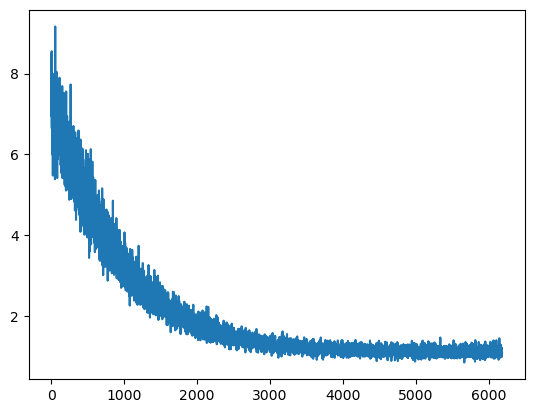

In [ ]:
y = 
x = range(1,len(y)+1)
plt.plot(x,y)
std=0.9
lr = 0.001